In [1]:
!pip install lightgbm xgboost pytorch-tabnet scikit-learn \
             pandas numpy matplotlib seaborn joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import os
import zipfile
warnings.filterwarnings('ignore')

In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score)
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.impute import SimpleImputer

In [4]:
import lightgbm as lgb
import xgboost as xgb
import joblib

In [5]:
try:
    import torch
    from pytorch_tabnet.tab_model import TabNetClassifier
    TABNET_AVAILABLE = True
    print(f"✅ TabNet available | PyTorch: {torch.__version__}")
except ImportError:
    TABNET_AVAILABLE = False
    print("⚠️  TabNet not installed. Will skip TabNet. Run: pip install pytorch-tabnet")

✅ TabNet available | PyTorch: 2.11.0+cu128


In [6]:
print(f"✅ LightGBM: {lgb.__version__}")
print(f"✅ XGBoost:  {xgb.__version__}")
print("✅ All core libraries loaded!")

✅ LightGBM: 4.6.0
✅ XGBoost:  3.2.0
✅ All core libraries loaded!


In [7]:
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})

In [8]:
COLORS = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
SEVERITY_LABELS = {0: 'Low', 1: 'Medium', 2: 'High', 3: 'Critical'}

In [11]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [12]:
CSV_PATH = '/Astram event data_anonymized - Astram event data_anonymizedb40ac87 (1).csv'   # ← CHANGE THIS to your filename

df_raw = pd.read_csv(CSV_PATH, low_memory=False)

print("✅ Dataset loaded!")
print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nAll columns ({len(df_raw.columns)}):")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

✅ Dataset loaded!
Shape: 8,173 rows × 46 columns

All columns (46):
   1. id
   2. event_type
   3. latitude
   4. longitude
   5. endlatitude
   6. endlongitude
   7. address
   8. end_address
   9. event_cause
  10. requires_road_closure
  11. start_datetime
  12. end_datetime
  13. status
  14. authenticated
  15. modified_datetime
  16. map_file
  17. direction
  18. description
  19. veh_type
  20. veh_no
  21. corridor
  22. priority
  23. cargo_material
  24. reason_breakdown
  25. age_of_truck
  26. created_date
  27. route_path
  28. client_id
  29. created_by_id
  30. last_modified_by_id
  31. assigned_to_police_id
  32. citizen_accident_id
  33. comment
  34. police_station
  35. meta_data
  36. kgid
  37. resolved_at_address
  38. resolved_at_latitude
  39. resolved_at_longitude
  40. closed_by_id
  41. closed_datetime
  42. resolved_by_id
  43. resolved_datetime
  44. gba_identifier
  45. zone
  46. junction


MISSING VALUE REPORT  (Total rows: 8,173)
               column  missing_n  missing_pct   dtype
              comment       8173        100.0 float64
             map_file       8173        100.0 float64
            meta_data       8173        100.0 float64
            direction       8130         99.5  object
  resolved_at_address       8099         99.1  object
 resolved_at_latitude       8099         99.1 float64
       resolved_by_id       8099         99.1  object
    resolved_datetime       8099         99.1  object
resolved_at_longitude       8099         99.1 float64
assigned_to_police_id       8045         98.4  object
  citizen_accident_id       8045         98.4  object
           route_path       8036         98.3  object
         age_of_truck       7897         96.6 float64
     reason_breakdown       7897         96.6  object
       cargo_material       7897         96.6  object
         end_datetime       7683         94.0  object
          end_address       7486        

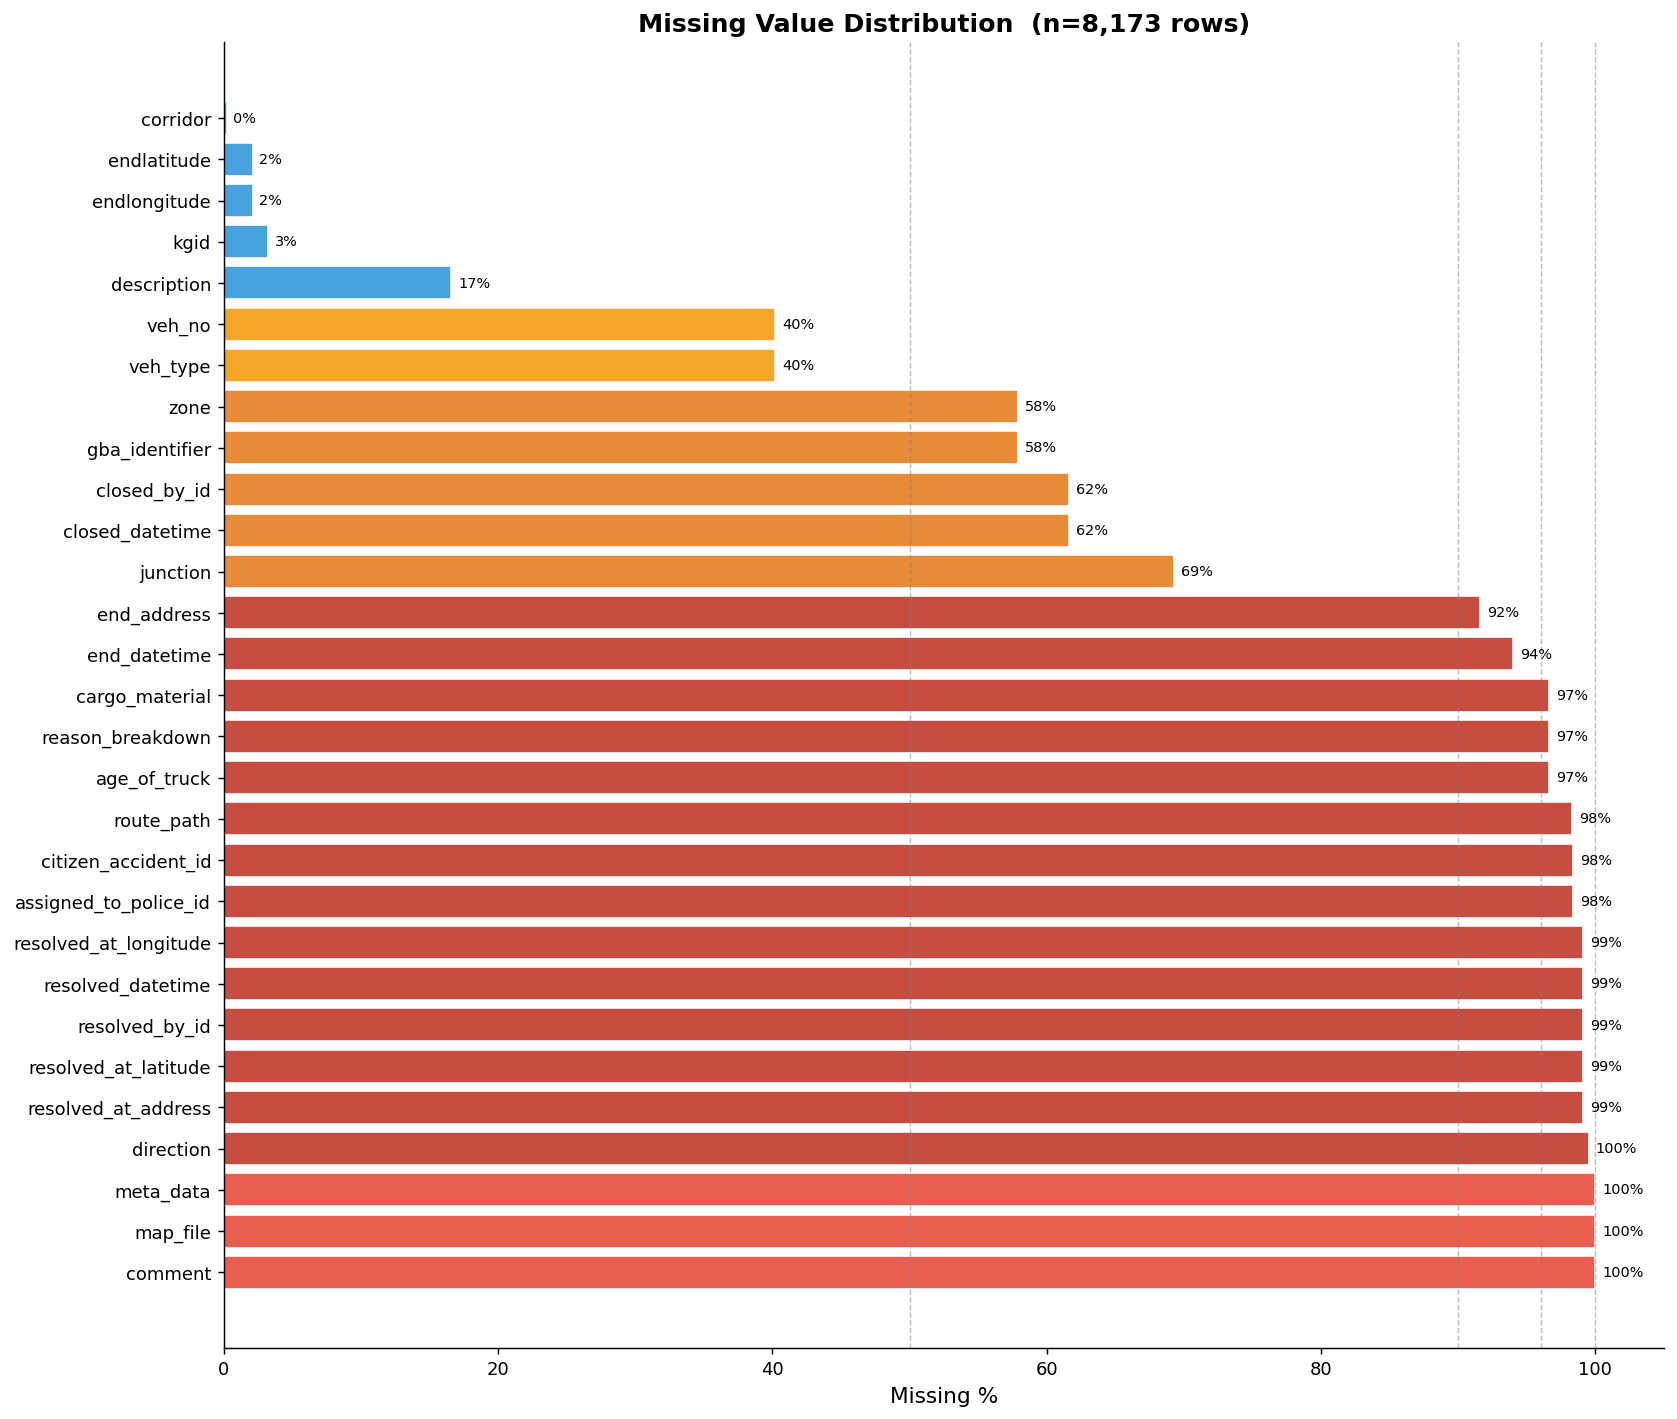

In [16]:
df = df_raw.copy()

missing = pd.DataFrame({
    'column':      df.columns,
    'missing_n':   df.isnull().sum().values,
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(1).values,
    'dtype':       df.dtypes.values
}).sort_values('missing_pct', ascending=False)

print("=" * 65)
print(f"MISSING VALUE REPORT  (Total rows: {len(df):,})")
print("=" * 65)
print(missing.to_string(index=False))

# ── Visualise ──────────────────────────────────────────
has_missing = missing[missing['missing_pct'] > 0].copy()

fig, ax = plt.subplots(figsize=(13, max(6, len(has_missing) * 0.38)))
bar_colors = [
    '#e74c3c' if x == 100 else
    '#c0392b' if x >= 90  else
    '#e67e22' if x >= 50  else
    '#f39c12' if x >= 20  else
    '#3498db'
    for x in has_missing['missing_pct']
]
bars = ax.barh(has_missing['column'], has_missing['missing_pct'],
               color=bar_colors, edgecolor='white', alpha=0.9)

for pct, label in [(100, '100% → DROP'), (96, '96%+'), (90, '90%'), (50, '50%')]:
    ax.axvline(pct, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

ax.set_xlabel('Missing %', fontsize=12)
ax.set_title(f'Missing Value Distribution  (n={len(df):,} rows)',
             fontsize=14, fontweight='bold')

for bar, val in zip(bars, has_missing['missing_pct']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('missing_values.png')
plt.show()

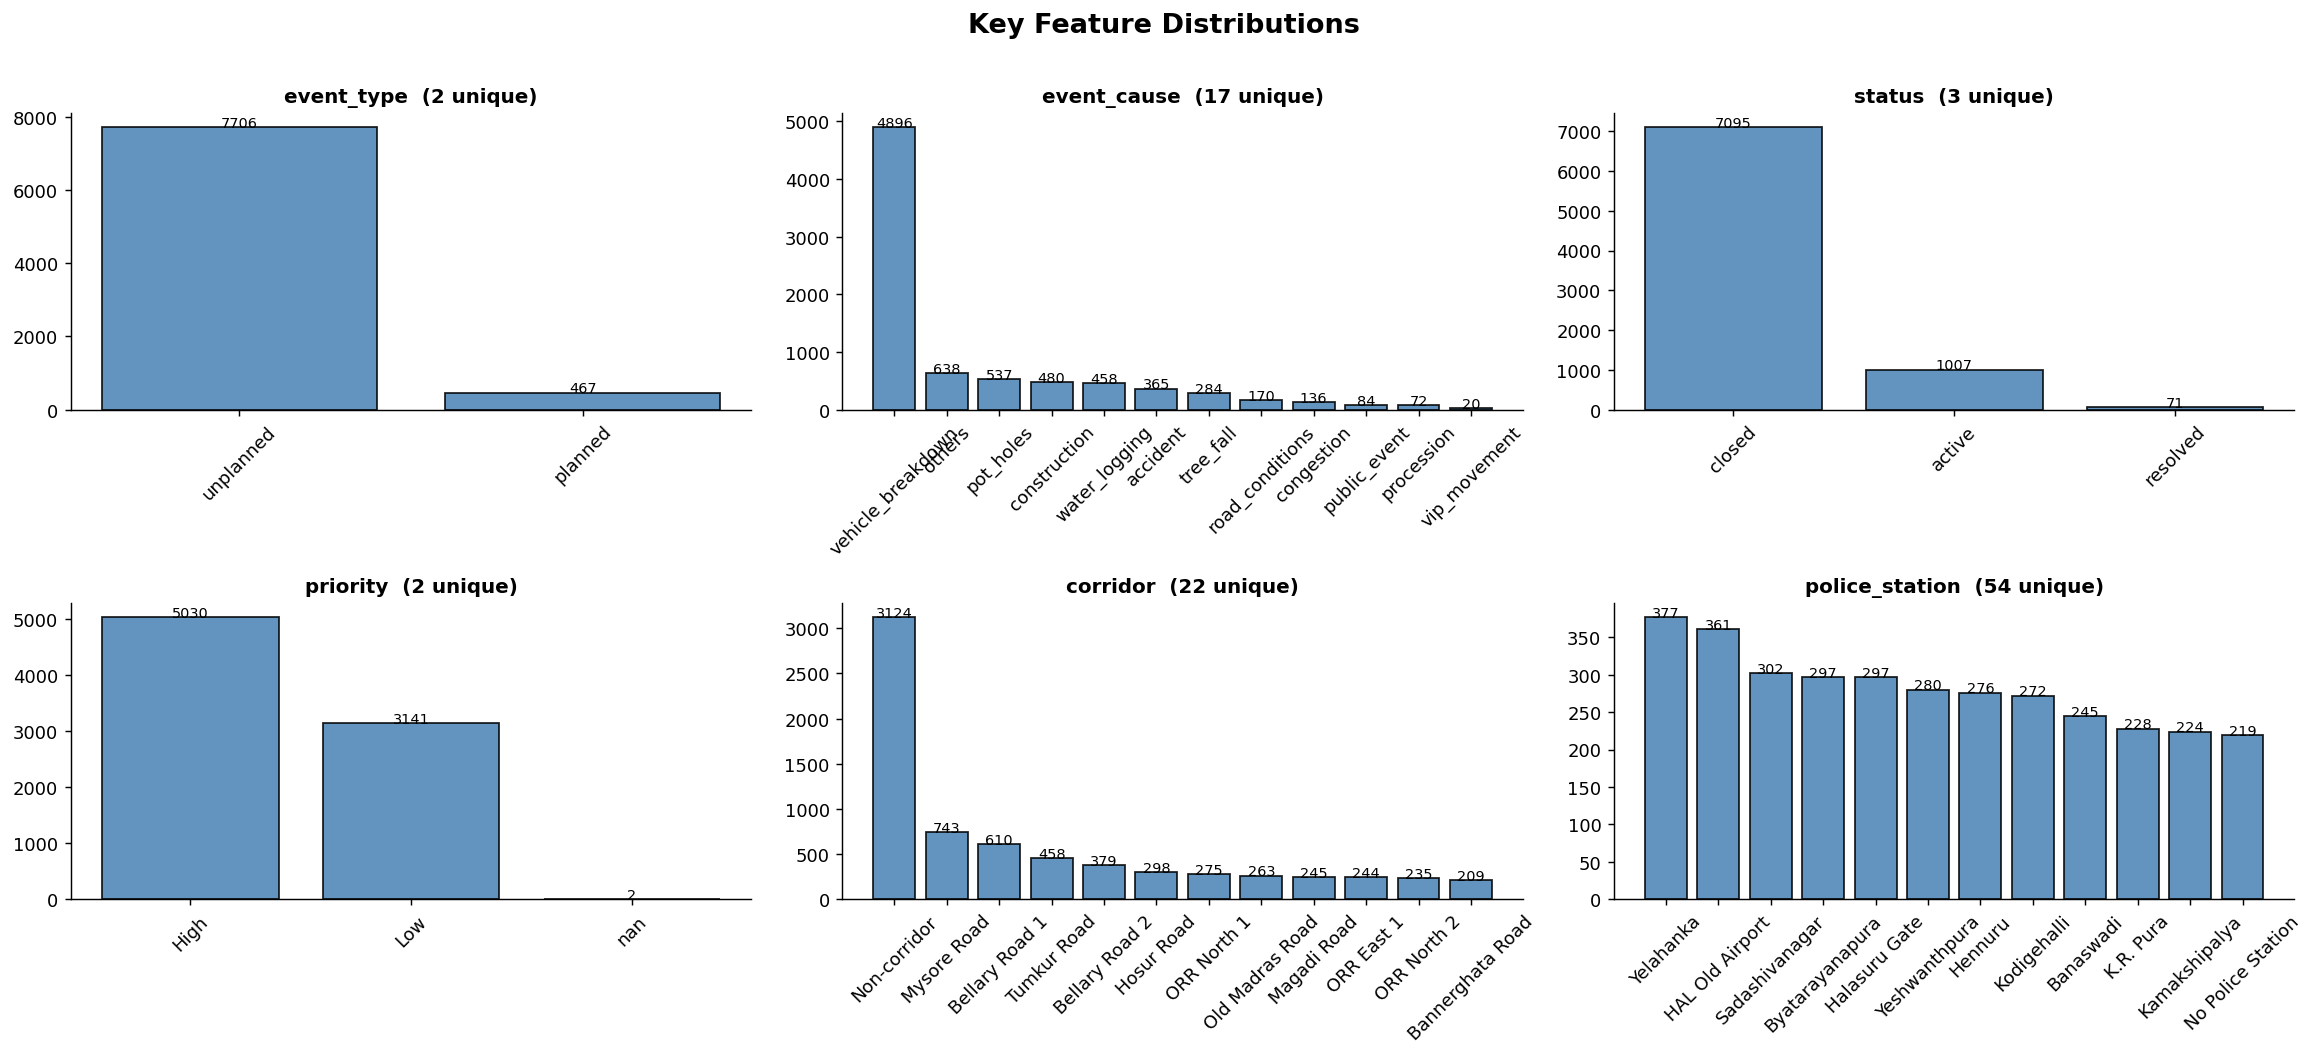

In [17]:
key_cats = ['event_type', 'event_cause', 'status',
            'priority', 'corridor', 'police_station']

n_c = 3
n_r = (len(key_cats) + n_c - 1) // n_c
fig, axes = plt.subplots(n_r, n_c, figsize=(18, n_r * 4))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    if col not in df.columns:
        axes[i].set_visible(False)
        continue
    vc = df[col].value_counts(dropna=False).head(12)
    axes[i].bar(vc.index.astype(str), vc.values,
                color='steelblue', edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col}  ({df[col].nunique()} unique)',
                      fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 0.3, str(v), ha='center', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Key Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

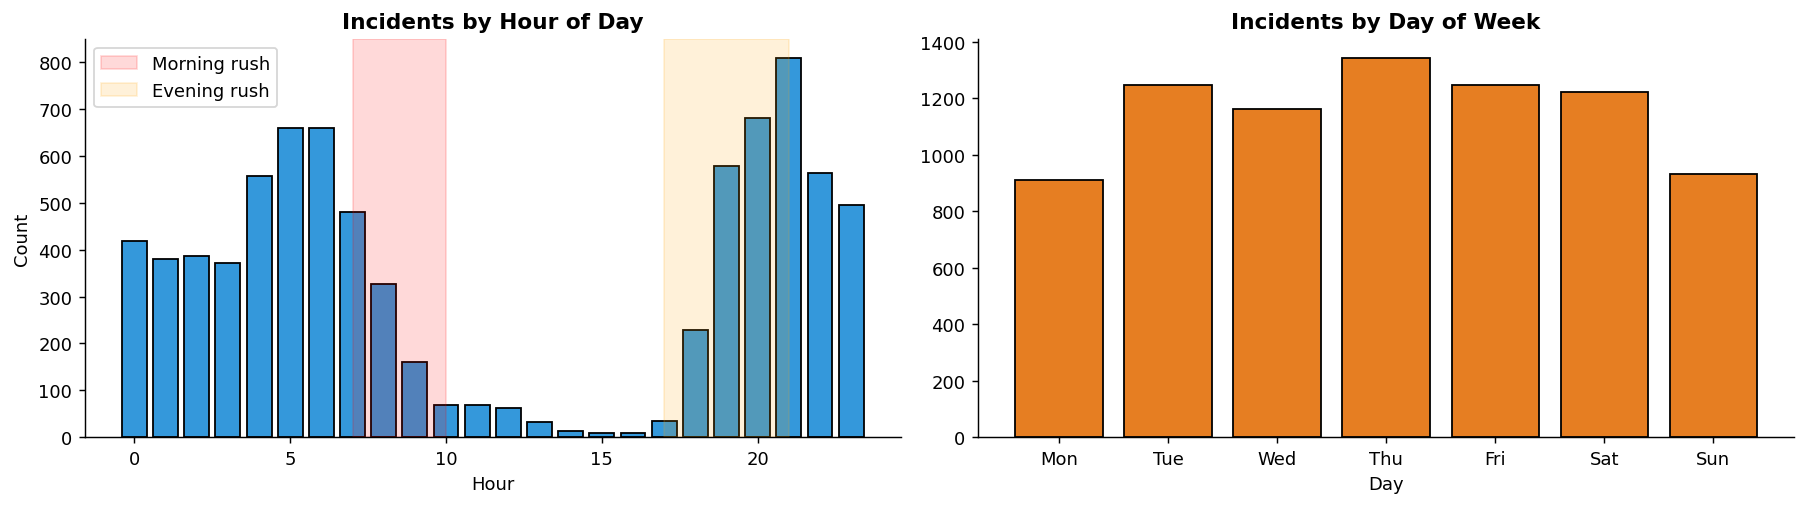

In [19]:
df['_start_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
hourly = df['_start_dt'].dt.hour.value_counts().sort_index()
daily  = df['_start_dt'].dt.dayofweek.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(hourly.index, hourly.values, color='#3498db', edgecolor='black')
axes[0].set_title('Incidents by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Count')
axes[0].axvspan(7, 10, alpha=0.15, color='red', label='Morning rush')
axes[0].axvspan(17, 21, alpha=0.15, color='orange', label='Evening rush')
axes[0].legend()

days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
axes[1].bar([days[int(d)] for d in daily.index], daily.values,
            color='#e67e22', edgecolor='black')
axes[1].set_title('Incidents by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day')

plt.tight_layout()
plt.savefig('temporal_overview.png')
plt.show()
df.drop(columns=['_start_dt'], inplace=True)

In [20]:
def time_bucket(hour):
    if pd.isna(hour): return 'unknown'
    h = int(hour)
    if  5 <= h <  9:  return 'early_morning'
    if  9 <= h < 12:  return 'morning'
    if 12 <= h < 15:  return 'afternoon'
    if 15 <= h < 19:  return 'evening'
    if 19 <= h < 22:  return 'night'
    return 'late_night'

def simplify_veh(v):
    """Collapse veh_type's 40.2% nulls + noise into 5 clean buckets."""
    if pd.isna(v): return 'unknown'
    v = str(v).lower()
    if 'bus' in v:                                      return 'bus'
    if any(w in v for w in ('truck','heavy','lcv')):   return 'heavy'
    if any(w in v for w in ('private','car')):         return 'private'
    if 'auto' in v:                                    return 'auto'
    return 'other'

def extract_pin(addr):
    """Pull 6-digit PIN from address string. Returns NaN if not found."""
    if pd.isna(addr): return np.nan
    m = re.search(r'Pin-(\d{6})', str(addr))
    return int(m.group(1)) if m else np.nan

In [25]:
DROP_DEFINITIVE = [
    # ── 100% missing ──
    'comment',                  # 100.0% → was wrongly used for has_com → FIXED
    'map_file',                 # 100.0%  (also seen as map_file_direction)
    'meta_data',                # 100.0%
    # ── >99% missing ──
    'direction',                # 99.5%  → NOT in previous version → ADDED
    'resolved_at_address',      # 99.1%
    'resolved_at_latitude',     # 99.1%
    'resolved_at_longitude',    # 99.1%
    'resolved_by_id',           # 99.1%
    'resolved_datetime',        # 99.1%
    'assigned_to_police_id',    # 98.4%
    'citizen_accident_id',      # 98.4%
    'route_path',               # 98.3%
    # ── ~96% missing ──
    'age_of_truck',             # 96.6%
    'reason_breakdown',         # 96.6% → has_rea would be 96.6% zeros → REMOVED
    'cargo_material',           # 96.6%
    # ── >90% missing ──
    'end_address',              # 91.6%
    # ── Pure identifiers (0% missing but zero predictive value) ──
    'id',
    'client_id',
    'created_by_id',
    'last_modified_by_id',
    'closed_by_id',
    'kgid',                     # 3.2% missing, internal ID → no geographic signal
    # ── Anonymised ──
    'veh_no',                   # 40.2% missing + anonymised
    # ── Post-event admin columns (leaky) ──
    'gba_identifier',           # 57.9% missing + admin code
]

# Handle alternate column names (CSV headers may vary)
alt_names = {'map_file_direction': 'map_file'}
for alt, canonical in alt_names.items():
    if alt in df.columns and canonical not in df.columns:
        DROP_DEFINITIVE = [canonical if x == canonical else x for x in DROP_DEFINITIVE]
        DROP_DEFINITIVE.append(alt)

drop_existing = [c for c in DROP_DEFINITIVE if c in df.columns]
df.drop(columns=drop_existing, inplace=True)
print(f"Dropped {len(drop_existing)} columns.")
print(f"Remaining: {df.shape[1]} columns — {list(df.columns)}")


Dropped 0 columns.
Remaining: 32 columns — ['event_type', 'latitude', 'longitude', 'event_cause', 'requires_road_closure', 'status', 'corridor', 'priority', 'police_station', 'zone', 'junction', 'hour', 'day_of_week', 'month', 'day', 'is_weekend', 'is_night', 'is_morning_rush', 'is_evening_rush', 'time_bucket', 'day_of_year', 'duration_mins', 'has_end_time', 'resolution_mins', 'has_been_closed', 'has_description', 'pin_code', 'has_end_location', 'location_cluster', 'is_corridor', 'veh_type_simple', 'authenticated_flag']


⚠️  start_datetime already processed — skipping STEP 3

Fitting KMeans with 20 clusters on 8,173 valid coords...
✅ 20 geo-clusters created over Bengaluru


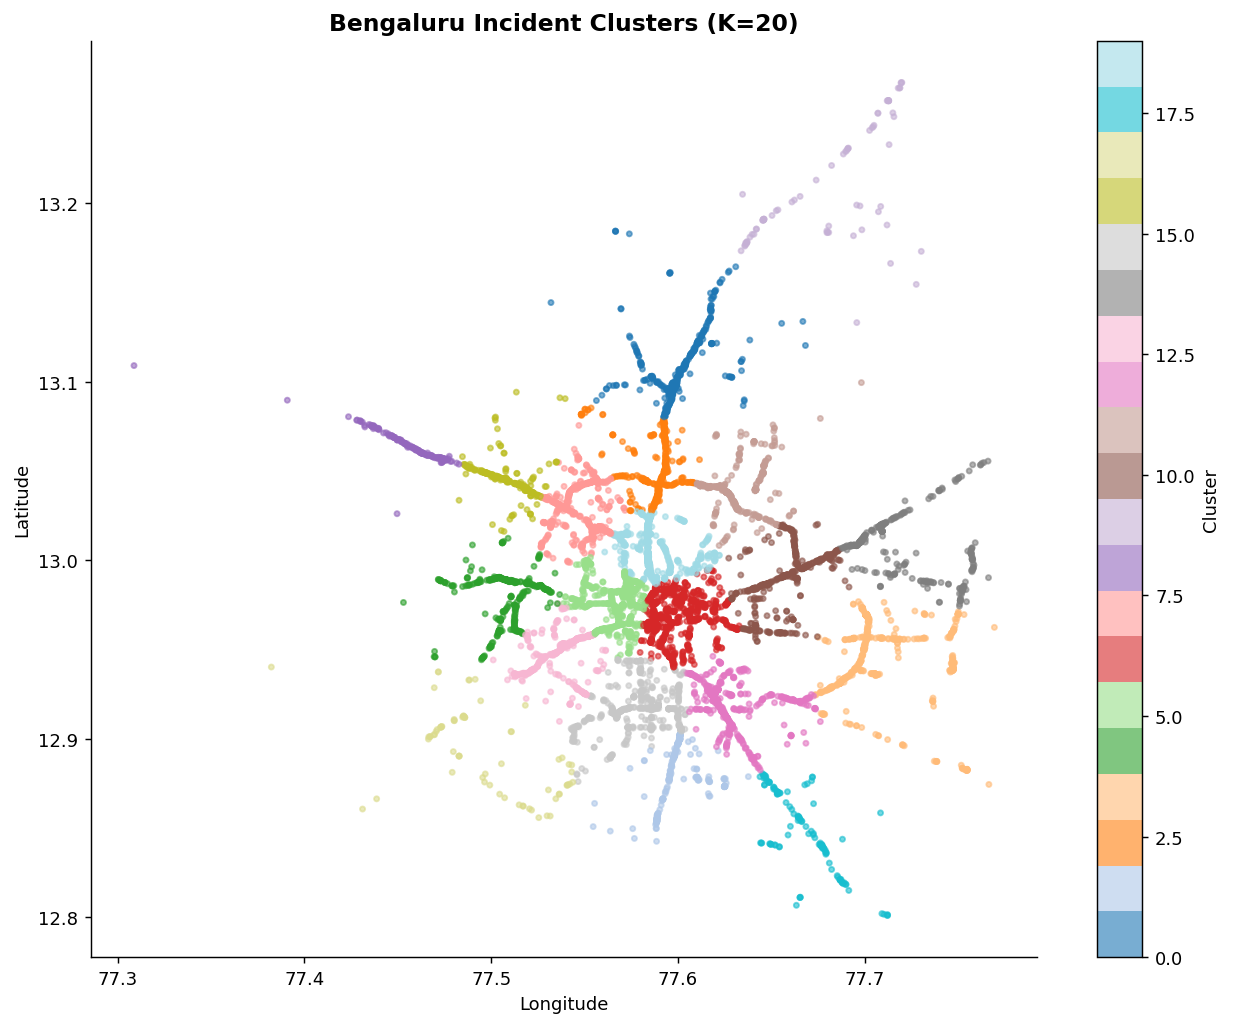

Crowd events flagged: 176 (2.2% of dataset)

✅ Feature engineering complete!
Dataset shape: (8173, 33)

Final columns:
  • event_type
  • latitude
  • longitude
  • event_cause
  • requires_road_closure
  • status
  • corridor
  • priority
  • police_station
  • zone
  • junction
  • hour
  • day_of_week
  • month
  • day
  • is_weekend
  • is_night
  • is_morning_rush
  • is_evening_rush
  • time_bucket
  • day_of_year
  • duration_mins
  • has_end_time
  • resolution_mins
  • has_been_closed
  • has_description
  • pin_code
  • has_end_location
  • location_cluster
  • is_corridor
  • veh_type_simple
  • authenticated_flag
  • is_crowd_event


In [28]:
DT_COLS = ['start_datetime', 'end_datetime',
           'closed_datetime', 'created_date', 'modified_datetime']
for col in DT_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')


# ────────────────────────────────────────────────────────
# STEP 3 — Temporal features from start_datetime (0% null)
# ────────────────────────────────────────────────────────


if 'start_datetime' in df.columns:
    df['hour']            = df['start_datetime'].dt.hour
    df['day_of_week']     = df['start_datetime'].dt.dayofweek
    df['month']           = df['start_datetime'].dt.month
    df['day']             = df['start_datetime'].dt.day
    df['is_weekend']      = (df['day_of_week'] >= 5).astype(int)
    df['is_night']        = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    df['is_morning_rush'] = ((df['hour'] >= 7) & (df['hour'] <= 10)).astype(int)
    df['is_evening_rush'] = ((df['hour'] >= 17) & (df['hour'] <= 21)).astype(int)
    df['time_bucket']     = df['hour'].apply(time_bucket)
    df['day_of_year']     = df['start_datetime'].dt.dayofyear
else:
    print("⚠️  start_datetime already processed — skipping STEP 3")


# ────────────────────────────────────────────────────────
# STEP 4 — Duration & resolution
# ────────────────────────────────────────────────────────

# end_datetime is 94% null → duration valid for only ~6% of rows.
# We still compute it for those 6%, impute rest with 0.
# has_end_time is the real signal here.
if 'end_datetime' in df.columns:
    df['duration_mins'] = (
        (df['end_datetime'] - df['start_datetime'])
        .dt.total_seconds() / 60
    ).clip(0, 1440)
    df['has_end_time'] = df['end_datetime'].notna().astype(int)
    df['duration_mins'] = df['duration_mins'].fillna(0)
else:
    df['duration_mins'] = 0
    df['has_end_time']  = 0

# closed_datetime is 61.6% null → valid for 38.4% of rows (real signal!)
# For events that are closed, resolution speed encodes severity indirectly.
if 'closed_datetime' in df.columns:
    df['resolution_mins'] = (
        (df['closed_datetime'] - df['start_datetime'])
        .dt.total_seconds() / 60
    ).clip(0, 1440)
    df['has_been_closed'] = df['closed_datetime'].notna().astype(int)
    df['resolution_mins'] = df['resolution_mins'].fillna(0)
else:
    df['resolution_mins'] = 0
    df['has_been_closed'] = 0


# ────────────────────────────────────────────────────────
# STEP 5 — Text presence features
# ────────────────────────────────────────────────────────

# ✅ description: 16.6% null → 83.4% populated = REAL SIGNAL
#    Events with descriptions are more thoroughly reported.
if 'description' in df.columns:
    df['has_description'] = df['description'].notna().astype(int)
else:
    df['has_description'] = 0

# ❌ comment: 100% null → DO NOT create has_comment (always 0 = useless)
# ❌ reason_breakdown: 96.6% null → DO NOT create has_reason (96.6% zeros)


# ────────────────────────────────────────────────────────
# STEP 6 — Spatial features
# ────────────────────────────────────────────────────────

# Extract PIN code from address (address is 0% null)
if 'address' in df.columns:
    df['pin_code'] = df['address'].apply(extract_pin)

# endlatitude / endlongitude — 2.1% null BUT many are 0,0 (fake null).
# We extract a binary flag and drop the raw values.
if 'endlatitude' in df.columns and 'endlongitude' in df.columns:
    df['has_end_location'] = (
        df['endlatitude'].notna() &
        df['endlongitude'].notna() &
        (df['endlatitude'] != 0) &
        (df['endlongitude'] != 0)
    ).astype(int)
    df.drop(columns=['endlatitude', 'endlongitude'], inplace=True)
else:
    df['has_end_location'] = 0

# KMeans geo-clustering on lat/lon (both 0% null = complete)
valid_geo = df[['latitude', 'longitude']].copy()
valid_geo = valid_geo[
    (valid_geo['latitude'] > 0) & (valid_geo['longitude'] > 0)
]

N_CLUSTERS = min(20, max(5, len(valid_geo) // 200))
print(f"\nFitting KMeans with {N_CLUSTERS} clusters on {len(valid_geo):,} valid coords...")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(valid_geo)
df.loc[valid_geo.index, 'location_cluster'] = cluster_labels
df['location_cluster'] = df['location_cluster'].fillna(-1).astype(int)
joblib.dump(kmeans, 'kmeans_model.pkl')
print(f"✅ {N_CLUSTERS} geo-clusters created over Bengaluru")

# Cluster visualisation
plt.figure(figsize=(10, 8))
scatter = plt.scatter(valid_geo['longitude'], valid_geo['latitude'],
                      c=cluster_labels, cmap='tab20', s=8, alpha=0.6)
plt.title(f'Bengaluru Incident Clusters (K={N_CLUSTERS})',
          fontsize=13, fontweight='bold')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('geo_clusters.png')
plt.show()


# ────────────────────────────────────────────────────────
# STEP 7 — Categorical feature engineering
# ────────────────────────────────────────────────────────

# corridor: 0.2% null → fillna 'Non-corridor'
if 'corridor' in df.columns:
    df['corridor'] = df['corridor'].fillna('Non-corridor')
    df['is_corridor'] = (df['corridor'] != 'Non-corridor').astype(int)

# zone: 57.9% null → fillna 'UNKNOWN' (keep it — police_station also encodes location)
if 'zone' in df.columns:
    df['zone'] = df['zone'].fillna('UNKNOWN')

# junction: 69.3% null → fillna 'UNKNOWN'
if 'junction' in df.columns:
    df['junction'] = df['junction'].fillna('UNKNOWN')

# veh_type: 40.2% null → simplify into 5 buckets
if 'veh_type' in df.columns:
    df['veh_type_simple'] = df['veh_type'].apply(simplify_veh)

CROWD_CAUSES = {'public_event', 'procession', 'vip_movement'}
df['is_crowd_event'] = df['event_cause'].isin(CROWD_CAUSES).astype(int)
print(f"Crowd events flagged: {df['is_crowd_event'].sum()} "
      f"({df['is_crowd_event'].mean()*100:.1f}% of dataset)")

# authenticated: 0% null, yes/no → binary
if 'authenticated' in df.columns:
    df['authenticated_flag'] = (
        df['authenticated'].astype(str).str.lower() == 'yes'
    ).astype(int)

# requires_road_closure: 0% null, already bool
if 'requires_road_closure' in df.columns:
    df['requires_road_closure'] = df['requires_road_closure'].astype(int)


# ────────────────────────────────────────────────────────
# STEP 8 — Drop raw columns after extraction
# ────────────────────────────────────────────────────────

EXTRACT_DROP = [
    'address',           # PIN extracted
    'description',       # has_description extracted
    'start_datetime',    # all temporal features extracted
    'end_datetime',      # has_end_time + duration_mins extracted
    'closed_datetime',   # has_been_closed + resolution_mins extracted
    'created_date',      # no signal beyond start_datetime
    'modified_datetime', # admin timestamp
    'veh_type',          # simplified into veh_type_simple
    'authenticated',     # binary flag extracted
]

df.drop(columns=[c for c in EXTRACT_DROP if c in df.columns], inplace=True)

print(f"\n✅ Feature engineering complete!")
print(f"Dataset shape: {df.shape}")
print(f"\nFinal columns:")
for c in df.columns:
    print(f"  • {c}")

TARGET: Severity Distribution
  0  Low        │ 2,764 (33.8%)  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  1  Medium     │   379 (4.6%)  ██████████████████
  2  High       │ 4,733 (57.9%)  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  3  Critical   │   297 (3.6%)  ██████████████


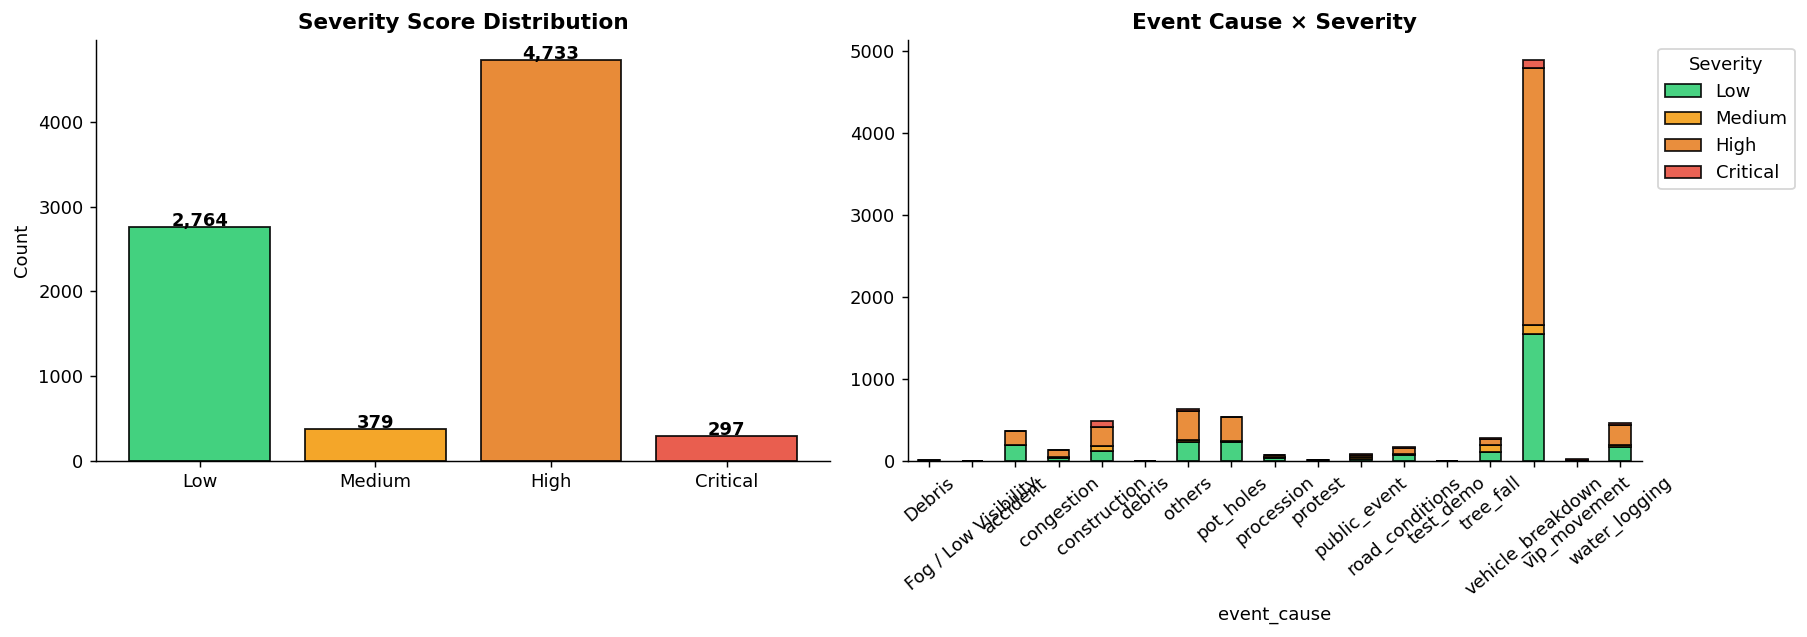

In [29]:
# ════════════════════════════════════════════════════════
# CELL 7 ▸ Target Variable — Severity Score (0–3)
# ════════════════════════════════════════════════════════
#
# WHY: Dataset has NO direct congestion/severity column.
# PROXY: We combine the two most informative zero-null columns:
#   priority            (High / Low) — 0% null
#   requires_road_closure (1 / 0)   — 0% null
#
# Result → 4-class severity that directly maps to resource decisions.
#
# ┌─────────────────────────────────────┬───────────────┐
# │ priority=Low  + closure=False  → 0  │  Low           │
# │ priority=Low  + closure=True   → 1  │  Medium        │
# │ priority=High + closure=False  → 2  │  High          │
# │ priority=High + closure=True   → 3  │  Critical      │
# └─────────────────────────────────────┴───────────────┘

def build_severity(row):
    high    = str(row.get('priority', '')).strip().lower() == 'high'
    closure = int(row.get('requires_road_closure', 0)) == 1
    if high and closure:      return 3
    if high and not closure:  return 2
    if not high and closure:  return 1
    return 0

df['severity'] = df.apply(build_severity, axis=1)

sev_counts = df['severity'].value_counts().sort_index()
print("=" * 55)
print("TARGET: Severity Distribution")
print("=" * 55)
for s, n in sev_counts.items():
    bar = '█' * (n // max(1, len(df) // 400))
    print(f"  {s}  {SEVERITY_LABELS[s]:10} │ {n:5,} ({n/len(df)*100:.1f}%)  {bar}")

# ── Visualise target ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar([SEVERITY_LABELS[i] for i in sev_counts.index],
            sev_counts.values,
            color=COLORS[:len(sev_counts)], edgecolor='black', alpha=0.9)
axes[0].set_title('Severity Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(sev_counts.values):
    axes[0].text(i, v + 5, f'{v:,}', ha='center', fontsize=10, fontweight='bold')

if 'event_cause' in df.columns:
    ct = pd.crosstab(df['event_cause'], df['severity'])
    ct.columns = [SEVERITY_LABELS[c] for c in ct.columns]
    ct.plot(kind='bar', ax=axes[1], stacked=True,
            color=COLORS[:ct.shape[1]], edgecolor='black', alpha=0.88)
    axes[1].set_title('Event Cause × Severity', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=40)
    axes[1].legend(title='Severity', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()

Using 30 features:
  ✅ latitude                  (nulls: 0)
  ✅ longitude                 (nulls: 0)
  ✅ location_cluster          (nulls: 0)
  ⚠️  pin_code                  (nulls: 149)
  ✅ has_end_location          (nulls: 0)
  ⚠️  hour                      (nulls: 116)
  ⚠️  day_of_week               (nulls: 116)
  ⚠️  month                     (nulls: 116)
  ⚠️  day                       (nulls: 116)
  ⚠️  day_of_year               (nulls: 116)
  ✅ is_weekend                (nulls: 0)
  ✅ is_night                  (nulls: 0)
  ✅ is_morning_rush           (nulls: 0)
  ✅ is_evening_rush           (nulls: 0)
  ✅ time_bucket               (nulls: 0)
  ✅ event_type                (nulls: 0)
  ✅ event_cause               (nulls: 0)
  ✅ is_corridor               (nulls: 0)
  ✅ authenticated_flag        (nulls: 0)
  ✅ has_description           (nulls: 0)
  ✅ has_end_time              (nulls: 0)
  ✅ has_been_closed           (nulls: 0)
  ✅ duration_mins             (nulls: 0)
  ✅ resolution

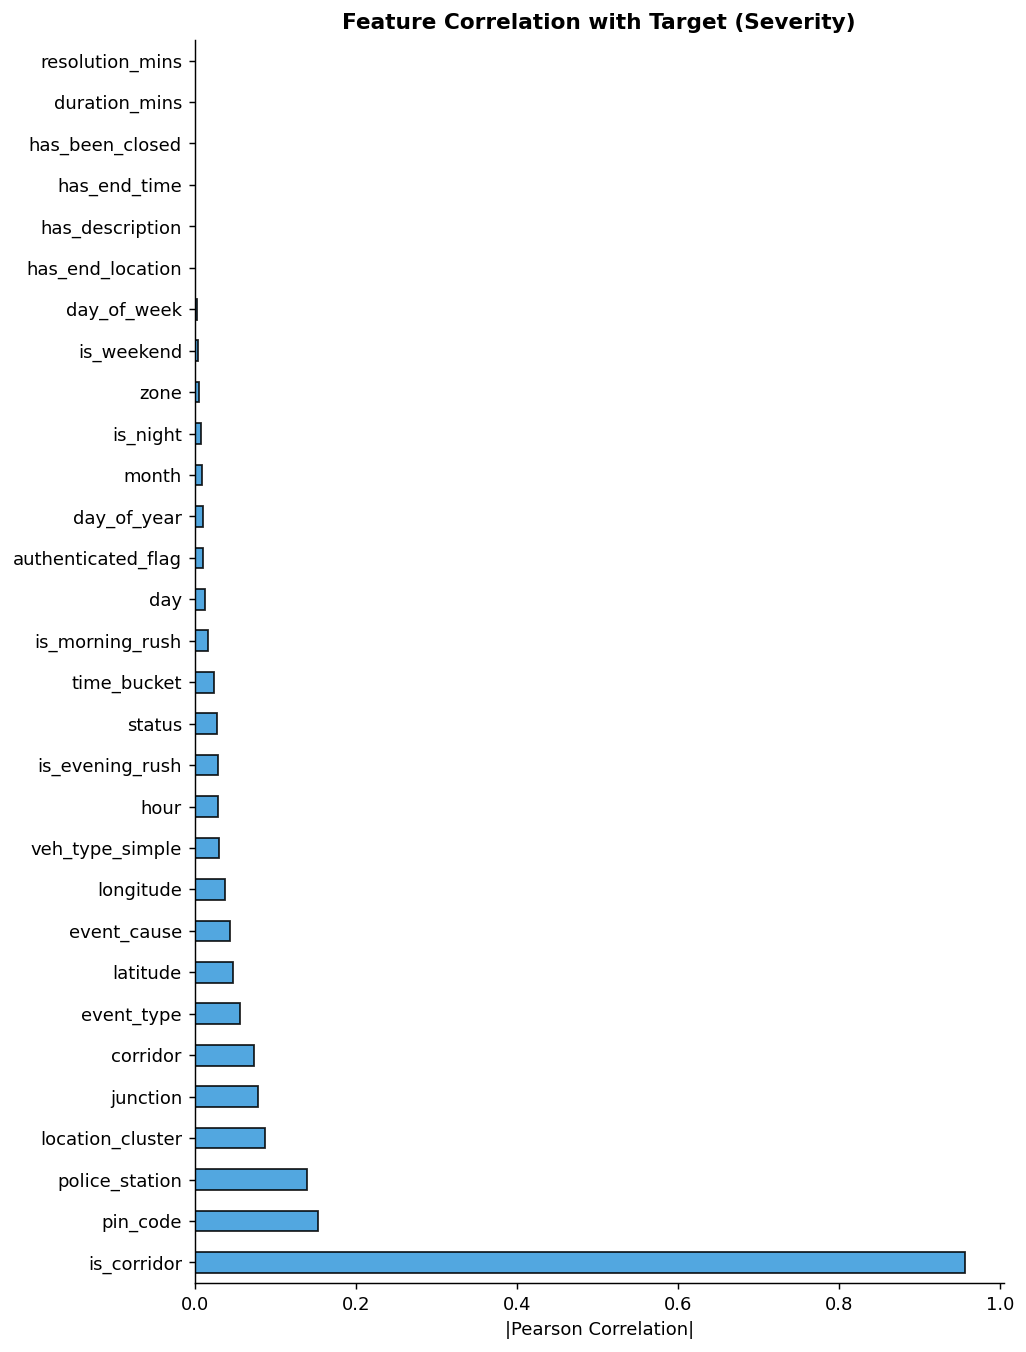

In [30]:
TARGET = 'severity'

# ── FINAL feature list (only columns that exist + have signal) ──
CANDIDATE_FEATURES = [
    # ── Spatial (0% null) ──────────────────────────
    'latitude', 'longitude', 'location_cluster',
    'pin_code',              # extracted from address
    'has_end_location',      # endlat/lon were mostly 0,0; binary flag instead
    # ── Temporal (0% null) ────────────────────────
    'hour', 'day_of_week', 'month', 'day', 'day_of_year',
    'is_weekend', 'is_night', 'is_morning_rush', 'is_evening_rush',
    'time_bucket',
    # ── Event identity (0% null) ──────────────────
    'event_type', 'event_cause',
    # ── Operational / flags ───────────────────────
    'is_corridor',           # binary: ORR/corridor vs local road
    'authenticated_flag',    # 0% null
    'has_description',       # 16.6% source-null → 83.4% populated = signal ✅
    'has_end_time',          # end_datetime 94% null → only 6% = 1; low but keep
    'has_been_closed',       # closed_datetime 61.6% null → 38.4% = 1; meaningful ✅
    # ── Duration / resolution ─────────────────────
    'duration_mins',         # 0 for 94% of rows (imputed); real for 6%
    'resolution_mins',       # real for 38.4% of rows
    # ── Categorical identifiers ───────────────────
    'corridor',              # 0.2% null filled; ORR East 1 / Bellary Rd / etc.
    'veh_type_simple',       # simplified from 40.2%-null veh_type
    'police_station',        # 0% null — strong location proxy
    'zone',                  # 57.9% null filled → UNKNOWN
    'junction',              # 69.3% null filled → UNKNOWN
    'status',                # 0% null
]

FEATURE_COLS = [c for c in CANDIDATE_FEATURES if c in df.columns]
print(f"Using {len(FEATURE_COLS)} features:")
for f in FEATURE_COLS:
    n_null = df[f].isnull().sum()
    print(f"  {'✅' if n_null == 0 else '⚠️ '} {f:<25} (nulls: {n_null})")

# ── Build model dataframe ─────────────────────────────
df_model = df[FEATURE_COLS + [TARGET]].copy()
df_model = df_model[df_model[TARGET].notna()].copy()
print(f"\nRows with valid target: {len(df_model):,}")

# ── Encode categoricals ───────────────────────────────
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f"\nEncoding {len(cat_cols)} categoricals: {cat_cols}")

label_encoders = {}
for col in cat_cols:
    df_model[col] = df_model[col].fillna('UNKNOWN').astype(str)
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

joblib.dump(label_encoders, 'label_encoders.pkl')

# ── Fill remaining numeric nulls with column median ───
num_cols = [c for c in df_model.select_dtypes(include=np.number).columns
            if c != TARGET]
for col in num_cols:
    med = df_model[col].median()
    df_model[col] = df_model[col].fillna(med)

# ── Sanity check ──────────────────────────────────────
remaining_nulls = df_model.isnull().sum().sum()
print(f"\n✅ Null count remaining: {remaining_nulls}")
print(f"Final model shape: {df_model.shape}")

# ── Correlation with target ───────────────────────────
corr_with_target = (df_model.corr()[TARGET]
                    .drop(TARGET)
                    .abs()
                    .sort_values(ascending=False))

plt.figure(figsize=(8, max(5, len(corr_with_target) * 0.35)))
corr_with_target.plot(kind='barh', color='#3498db', edgecolor='black', alpha=0.85)
plt.title('Feature Correlation with Target (Severity)', fontsize=12, fontweight='bold')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.savefig('feature_target_correlation.png')
plt.show()

In [31]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET].astype(int)

FEATURE_NAMES = X.columns.tolist()
joblib.dump(FEATURE_NAMES, 'feature_names.pkl')

print("Class distribution:")
for c, n in y.value_counts().sort_index().items():
    print(f"  {c}  {SEVERITY_LABELS[c]:10}: {n:5,}  ({n/len(y)*100:.1f}%)")

# Stratified split preserves class ratios even with imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}")

# Scale for DL models (tree models don't need scaling)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved")

Class distribution:
  0  Low       : 2,764  (33.8%)
  1  Medium    :   379  (4.6%)
  2  High      : 4,733  (57.9%)
  3  Critical  :   297  (3.6%)

Train: 6,538  |  Test: 1,635
✅ Scaler saved


MODEL 1: LightGBM Classifier
[200]	valid_0's multi_logloss: 0.256131

Accuracy  : 0.9223
F1 (macro): 0.6949
F1 (wtd)  : 0.9148

Classification Report:
              precision    recall  f1-score   support

         Low       0.92      0.96      0.94       553
      Medium       0.58      0.39      0.47        76
        High       0.96      0.98      0.97       947
    Critical       0.54      0.32      0.40        59

    accuracy                           0.92      1635
   macro avg       0.75      0.66      0.69      1635
weighted avg       0.91      0.92      0.91      1635



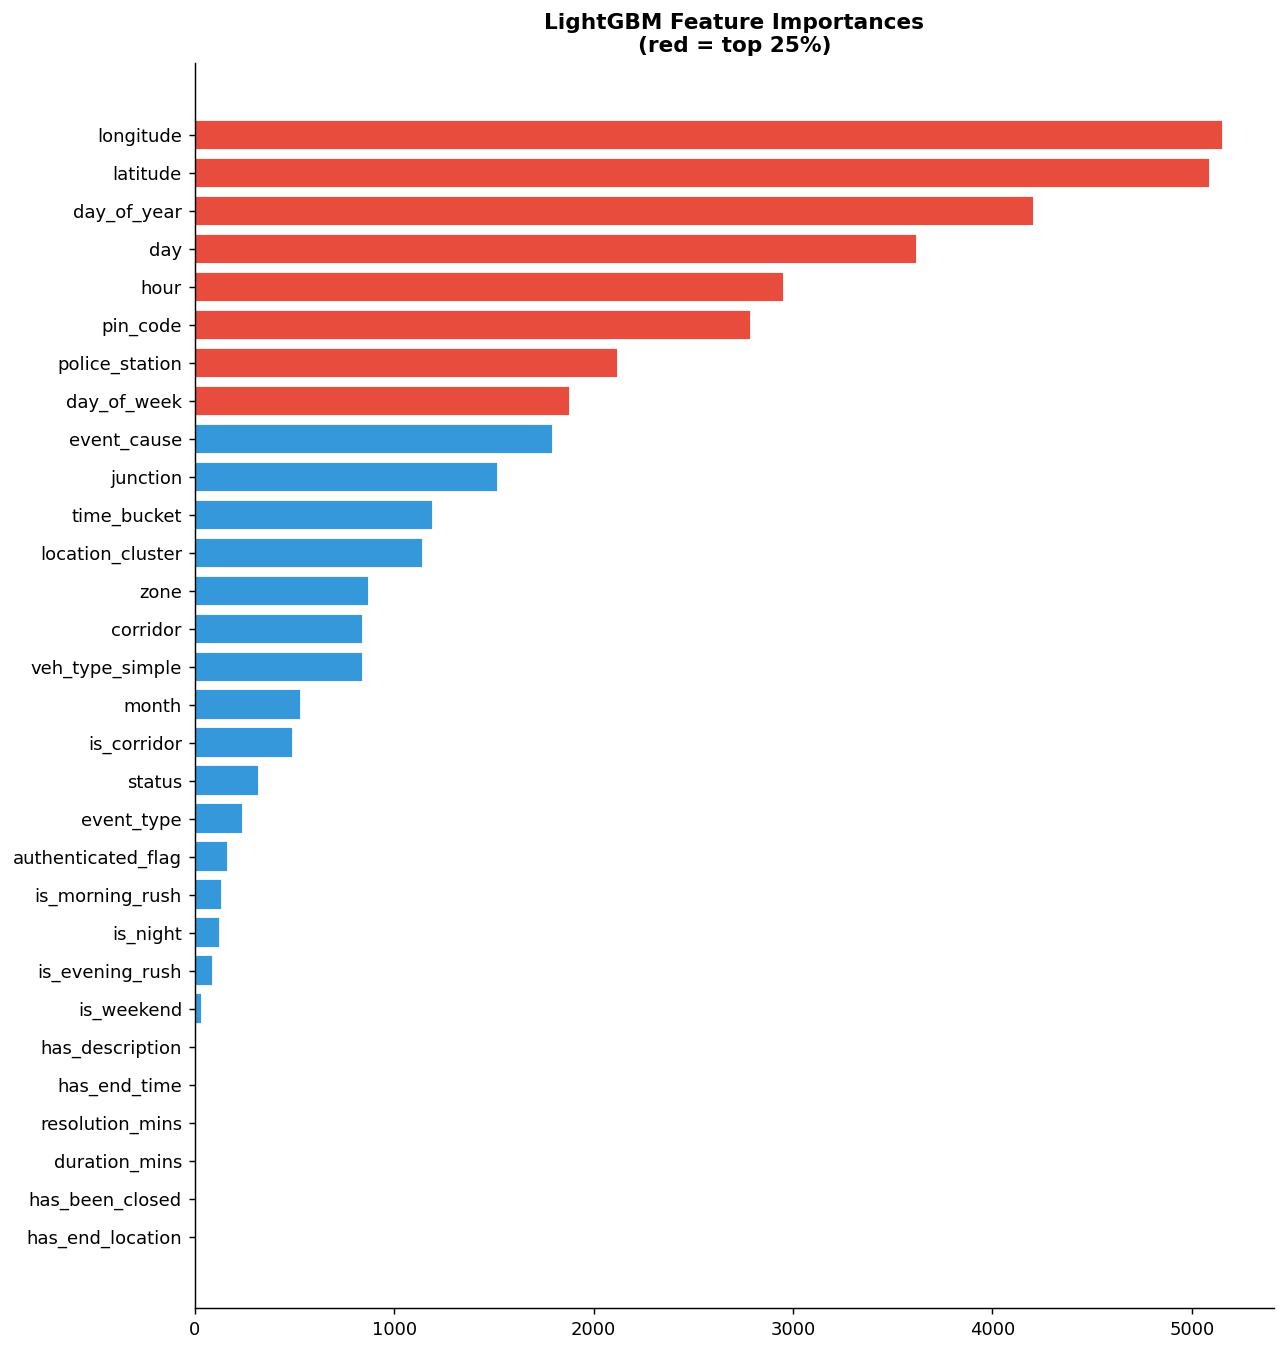

✅ Saved: lgbm_model.pkl + lgbm_model.txt


In [32]:
# CELL 10 ▸ MODEL 1 — LightGBM
# ════════════════════════════════════════════════════════
# WHY LightGBM first:
#   • Handles sparse/imputed numerics natively
#   • Class-weight balancing built in
#   • Fastest to train + tune
#   • Historically best single-model on tabular data of this size

print("=" * 60)
print("MODEL 1: LightGBM Classifier")
print("=" * 60)

lgb_params = {
    'objective':        'multiclass',
    'num_class':         4,
    'metric':           'multi_logloss',
    'num_leaves':        63,
    'learning_rate':     0.03,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'min_child_samples': 15,
    'n_estimators':      1000,
    'random_state':      42,
    'class_weight':     'balanced',
    'verbose':          -1,
    'reg_alpha':         0.1,
    'reg_lambda':        0.1,
}

lgbm = lgb.LGBMClassifier(**lgb_params)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(80, verbose=False),
        lgb.log_evaluation(200),
    ]
)

lgbm_preds = lgbm.predict(X_test)
lgbm_probs = lgbm.predict_proba(X_test)

print(f"\nAccuracy  : {accuracy_score(y_test, lgbm_preds):.4f}")
print(f"F1 (macro): {f1_score(y_test, lgbm_preds, average='macro'):.4f}")
print(f"F1 (wtd)  : {f1_score(y_test, lgbm_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lgbm_preds,
      target_names=[SEVERITY_LABELS[i] for i in range(4)]))

# Feature importance
fi_df = pd.DataFrame({'feature': FEATURE_NAMES,
                      'importance': lgbm.feature_importances_}
                     ).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(5, len(fi_df) * 0.35)))
colors_fi = ['#e74c3c' if imp > fi_df['importance'].quantile(0.75)
             else '#3498db' for imp in fi_df['importance']]
ax.barh(fi_df['feature'], fi_df['importance'],
        color=colors_fi, edgecolor='white')
ax.set_title('LightGBM Feature Importances\n(red = top 25%)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png')
plt.show()

lgbm.booster_.save_model('lgbm_model.txt')
joblib.dump(lgbm, 'lgbm_model.pkl')
print("✅ Saved: lgbm_model.pkl + lgbm_model.txt")



In [33]:
print("=" * 60)
print("MODEL 2: XGBoost Classifier")
print("=" * 60)

sw_train = compute_sample_weight('balanced', y_train)

xgbm = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    early_stopping_rounds=80,
    verbosity=0,
    use_label_encoder=False,
)
xgbm.fit(X_train, y_train,
         sample_weight=sw_train,
         eval_set=[(X_test, y_test)],
         verbose=200)

xgb_preds = xgbm.predict(X_test)
xgb_probs = xgbm.predict_proba(X_test)

print(f"\nAccuracy  : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"F1 (macro): {f1_score(y_test, xgb_preds, average='macro'):.4f}")
print(f"F1 (wtd)  : {f1_score(y_test, xgb_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=[SEVERITY_LABELS[i] for i in range(4)]))

xgbm.save_model('xgb_model.json')
joblib.dump(xgbm, 'xgb_model.pkl')
print("✅ Saved: xgb_model.pkl + xgb_model.json")

MODEL 2: XGBoost Classifier
[0]	validation_0-mlogloss:1.35414
[200]	validation_0-mlogloss:0.34533
[400]	validation_0-mlogloss:0.28054
[600]	validation_0-mlogloss:0.26288
[686]	validation_0-mlogloss:0.26391

Accuracy  : 0.9168
F1 (macro): 0.6906
F1 (wtd)  : 0.9114

Classification Report:
              precision    recall  f1-score   support

         Low       0.92      0.96      0.94       553
      Medium       0.56      0.39      0.46        76
        High       0.96      0.97      0.97       947
    Critical       0.46      0.36      0.40        59

    accuracy                           0.92      1635
   macro avg       0.72      0.67      0.69      1635
weighted avg       0.91      0.92      0.91      1635

✅ Saved: xgb_model.pkl + xgb_model.json


MODEL 3: MLP Neural Network
Iteration 1, loss = 0.58492887
Validation score: 0.911315
Iteration 2, loss = 0.26146273
Validation score: 0.914373
Iteration 3, loss = 0.24522981
Validation score: 0.911315
Iteration 4, loss = 0.23584917
Validation score: 0.911315
Iteration 5, loss = 0.22776701
Validation score: 0.906218
Iteration 6, loss = 0.21946419
Validation score: 0.911315
Iteration 7, loss = 0.21851195
Validation score: 0.909276
Iteration 8, loss = 0.20636158
Validation score: 0.909276
Iteration 9, loss = 0.20093565
Validation score: 0.903160
Iteration 10, loss = 0.19499328
Validation score: 0.908257
Iteration 11, loss = 0.18876872
Validation score: 0.905199
Iteration 12, loss = 0.17479734
Validation score: 0.908257
Iteration 13, loss = 0.17002066
Validation score: 0.907238
Iteration 14, loss = 0.17359580
Validation score: 0.903160
Iteration 15, loss = 0.15653256
Validation score: 0.898063
Iteration 16, loss = 0.14344295
Validation score: 0.898063
Iteration 17, loss = 0.13722799
Valid

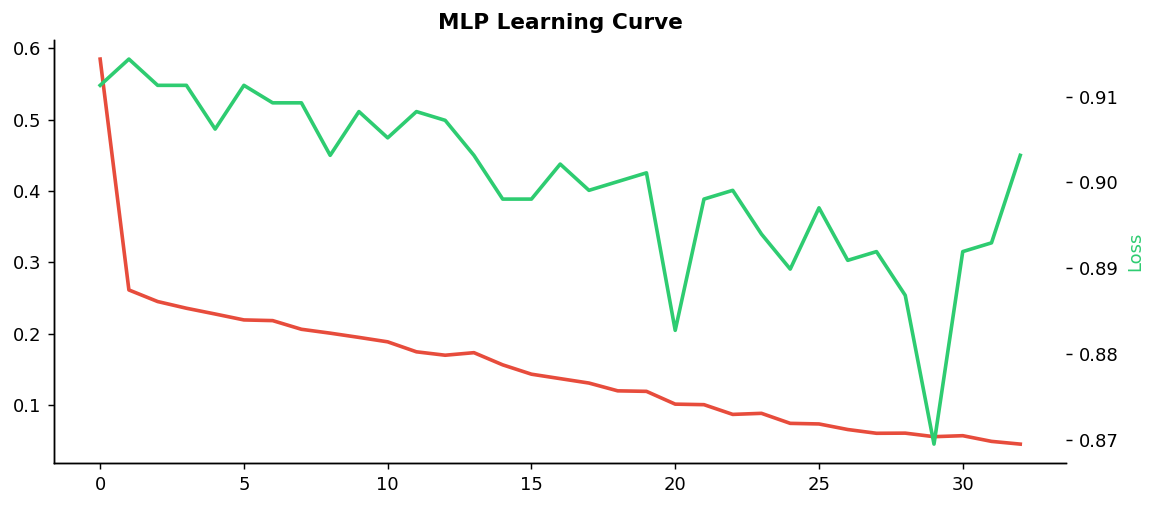

✅ Saved: mlp_model.pkl


In [34]:
# CELL 12 ▸ MODEL 3 — MLP Neural Network
# ════════════════════════════════════════════════════════
# WHY: Learns interaction patterns between zone×hour×event_cause
# that tree models may miss with linear splits.
# Uses SCALED features (StandardScaler applied in Cell 9).

print("=" * 60)
print("MODEL 3: MLP Neural Network")
print("=" * 60)

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    batch_size=128,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=42,
    verbose=True,
)
mlp.fit(X_train_sc, y_train)

mlp_preds = mlp.predict(X_test_sc)
mlp_probs = mlp.predict_proba(X_test_sc)

print(f"\nAccuracy  : {accuracy_score(y_test, mlp_preds):.4f}")
print(f"F1 (macro): {f1_score(y_test, mlp_preds, average='macro'):.4f}")
print(f"F1 (wtd)  : {f1_score(y_test, mlp_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, mlp_preds,
      target_names=[SEVERITY_LABELS[i] for i in range(4)]))

plt.figure(figsize=(9, 4))
plt.plot(mlp.loss_curve_, label='Training Loss', color='#e74c3c', linewidth=2)
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    ax2 = plt.gca().twinx()
    ax2.plot(mlp.validation_scores_, label='Val Accuracy',
             color='#2ecc71', linewidth=2)
    ax2.set_ylabel('Val Accuracy', color='#2ecc71')
plt.title('MLP Learning Curve', fontsize=12, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('mlp_learning_curve.png')
plt.show()

joblib.dump(mlp, 'mlp_model.pkl')
print("✅ Saved: mlp_model.pkl")

MODEL 4: TabNet  (Attention-based Tabular DL)
Device: cuda
epoch 0  | loss: 1.73205 | val_0_accuracy: 0.55168 |  0:00:02s
epoch 10 | loss: 0.45569 | val_0_accuracy: 0.87951 |  0:00:08s
epoch 20 | loss: 0.31907 | val_0_accuracy: 0.90581 |  0:00:15s
epoch 30 | loss: 0.28536 | val_0_accuracy: 0.91376 |  0:00:21s
epoch 40 | loss: 0.26532 | val_0_accuracy: 0.91682 |  0:00:29s
epoch 50 | loss: 0.26004 | val_0_accuracy: 0.91988 |  0:00:35s
epoch 60 | loss: 0.26541 | val_0_accuracy: 0.91988 |  0:00:42s
epoch 70 | loss: 0.25203 | val_0_accuracy: 0.92171 |  0:00:49s
epoch 80 | loss: 0.24076 | val_0_accuracy: 0.92232 |  0:00:56s
epoch 90 | loss: 0.23467 | val_0_accuracy: 0.91927 |  0:01:03s
epoch 100| loss: 0.22808 | val_0_accuracy: 0.91988 |  0:01:09s

Early stopping occurred at epoch 103 with best_epoch = 73 and best_val_0_accuracy = 0.92538

Accuracy  : 0.9254
F1 (macro): 0.6027
F1 (wtd)  : 0.9020

Classification Report:
              precision    recall  f1-score   support

         Low      

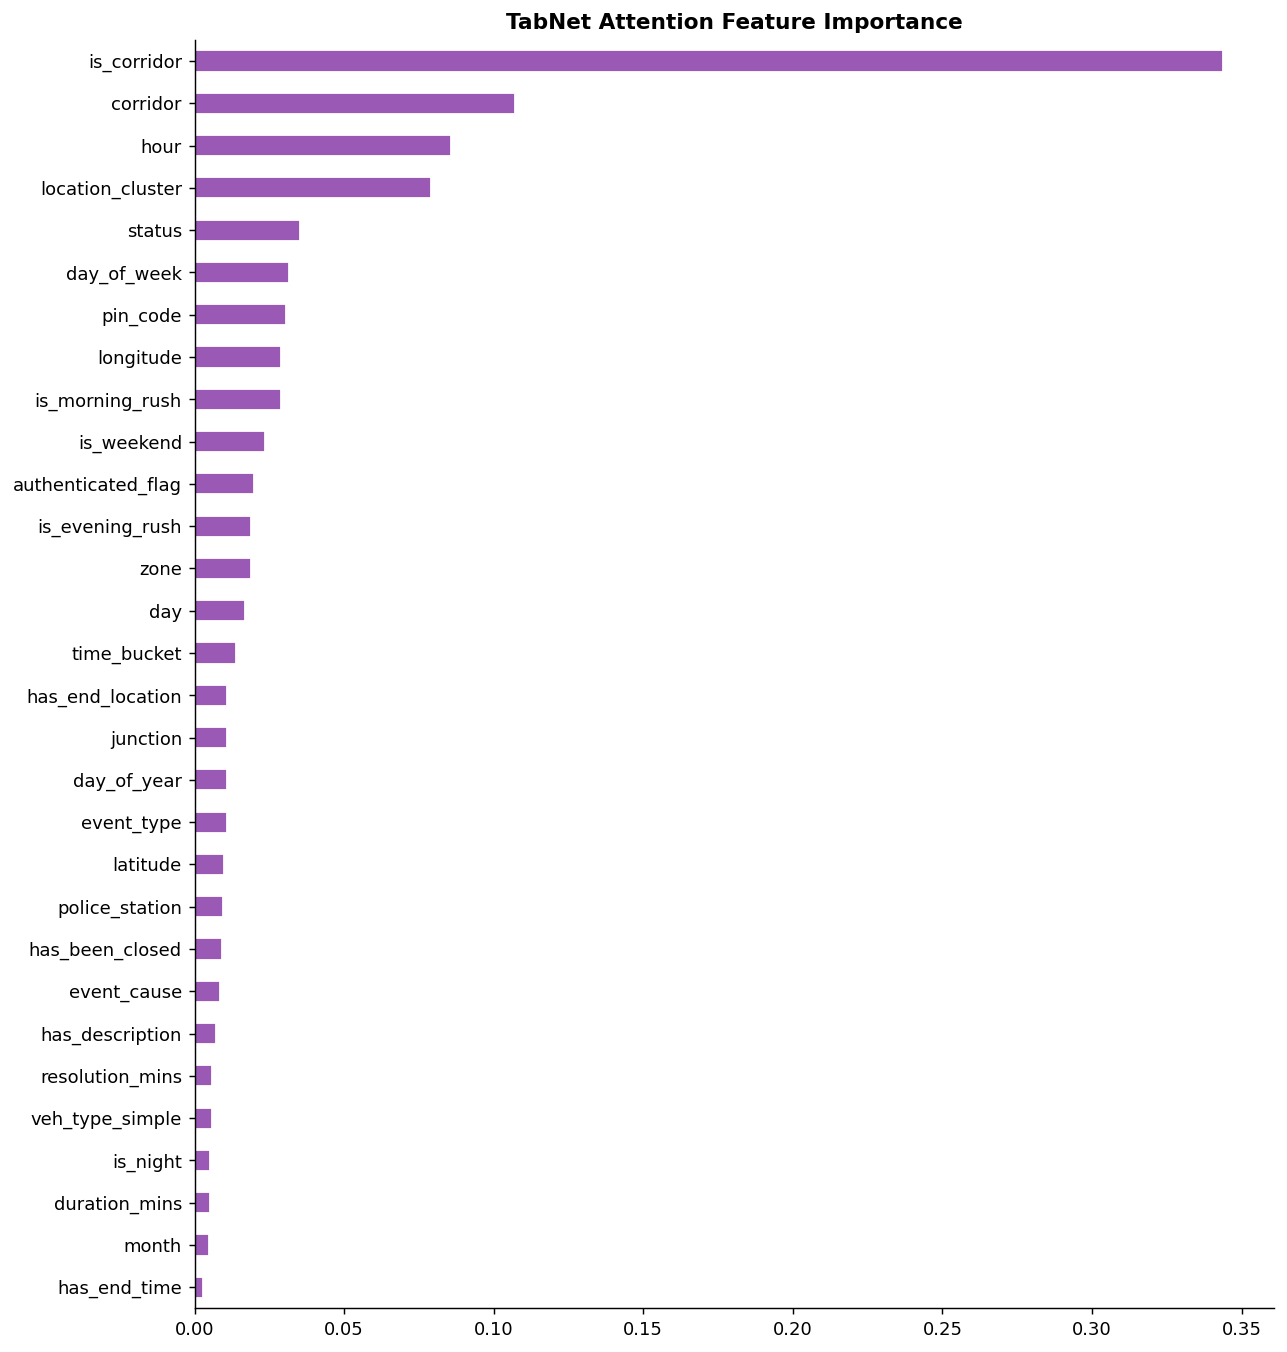

Successfully saved model at tabnet_model.zip
✅ Saved: tabnet_model.zip


In [36]:
#WHY TabNet:
#   • Per-sample attention mechanism → interprets WHICH features
#     drove each prediction (great for hackathon explainability)
#   • Handles the sparse nature of our dataset (many binary flags)
#   • Install: pip install pytorch-tabnet

if TABNET_AVAILABLE:
    print("=" * 60)
    print("MODEL 4: TabNet  (Attention-based Tabular DL)")
    print("=" * 60)

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Device: {device}")

    tabnet = TabNetClassifier(
        n_d=32, n_a=32,
        n_steps=5,
        gamma=1.5,
        n_independent=2,
        n_shared=2,
        momentum=0.02,
        lambda_sparse=1e-3,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-3, weight_decay=1e-5),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 50, "gamma": 0.9},
        seed=42,
        verbose=10,
        device_name=device,
    )

    tabnet.fit(
        X_train_sc, y_train.values,
        eval_set=[(X_test_sc, y_test.values)],
        eval_metric=['accuracy'],
        max_epochs=200,
        patience=30,
        batch_size=512,
        virtual_batch_size=128,
    )

    tn_preds = tabnet.predict(X_test_sc)
    tn_probs = tabnet.predict_proba(X_test_sc)

    print(f"\nAccuracy  : {accuracy_score(y_test, tn_preds):.4f}")
    print(f"F1 (macro): {f1_score(y_test, tn_preds, average='macro'):.4f}")
    print(f"F1 (wtd)  : {f1_score(y_test, tn_preds, average='weighted'):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, tn_preds,
          target_names=[SEVERITY_LABELS[i] for i in range(4)]))

    # Attention-based importance
    plt.figure(figsize=(10, max(5, len(FEATURE_NAMES) * 0.35)))
    fi_tn = pd.Series(tabnet.feature_importances_, index=FEATURE_NAMES
                      ).sort_values(ascending=True)
    fi_tn.plot(kind='barh', color='#9b59b6', edgecolor='white')
    plt.title('TabNet Attention Feature Importance', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('tabnet_feature_importance.png')
    plt.show()

    tabnet.save_model('tabnet_model')
    print("✅ Saved: tabnet_model.zip")
else:
    print("⚠️  TabNet skipped.")
    tn_probs = None


In [37]:
# ════════════════════════════════════════════════════════
# CELL 14 ▸ MODEL 5 — Stacked Ensemble (OOF meta-learner)
# ════════════════════════════════════════════════════════
# Strategy:
#   1. Generate Out-of-Fold (OOF) probabilities via 5-fold CV.
#      This prevents leakage — models never see their own training
#      data when generating meta-features.
#   2. Stack all model probs → LightGBM meta-learner.
#   3. Meta-learner learns WHEN to trust which model.

print("=" * 60)
print("MODEL 5: Stacked Ensemble (5-fold OOF meta-learner)")
print("=" * 60)

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

N_MODELS = 3 + int(TABNET_AVAILABLE)
oof_probs   = np.zeros((len(X_train), 4 * N_MODELS))
oof_sources = ['LGBM', 'XGB', 'MLP'] + (['TabNet'] if TABNET_AVAILABLE else [])

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    Xf_tr,  Xf_val  = X_train.iloc[tr_idx],  X_train.iloc[val_idx]
    yf_tr,  yf_val  = y_train.iloc[tr_idx],  y_train.iloc[val_idx]
    Xf_trs  = scaler.transform(Xf_tr).astype(np.float32)
    Xf_vals = scaler.transform(Xf_val).astype(np.float32)

    # ── LightGBM fold ──
    lf = lgb.LGBMClassifier(**lgb_params)
    lf.fit(Xf_tr, yf_tr,
           eval_set=[(Xf_val, yf_val)],
           callbacks=[lgb.early_stopping(60, verbose=False),
                      lgb.log_evaluation(-1)])
    p_lgbm = lf.predict_proba(Xf_val)

    # ── XGBoost fold ──
    xf = xgb.XGBClassifier(objective='multi:softprob', num_class=4,
                            n_estimators=400, learning_rate=0.05,
                            max_depth=6, subsample=0.8, verbosity=0,
                            use_label_encoder=False, random_state=42)
    xf.fit(Xf_tr, yf_tr, sample_weight=compute_sample_weight('balanced', yf_tr))
    p_xgb = xf.predict_proba(Xf_val)

    # ── MLP fold ──
    mf = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300,
                       early_stopping=True, random_state=42, verbose=False)
    mf.fit(Xf_trs, yf_tr)
    p_mlp = mf.predict_proba(Xf_vals)

    blocks = [p_lgbm, p_xgb, p_mlp]

    # ── TabNet fold (if available) ──
    if TABNET_AVAILABLE:
        tf = TabNetClassifier(n_d=16, n_a=16, n_steps=3, seed=42,
                              verbose=0, device_name=device)
        tf.fit(Xf_trs, yf_tr.values,
               max_epochs=100, patience=20, batch_size=256,
               virtual_batch_size=128)
        blocks.append(tf.predict_proba(Xf_vals))

    oof_probs[val_idx] = np.hstack(blocks)
    print(f"  Fold {fold}/{N_FOLDS} done — OOF shape so far OK")

# ── Test meta-features ────────────────────────────────
test_blocks = [lgbm_probs, xgb_probs, mlp_probs]
if TABNET_AVAILABLE and tn_probs is not None:
    test_blocks.append(tn_probs)
meta_test = np.hstack(test_blocks)

# ── Train meta-learner ────────────────────────────────
meta_lgb = lgb.LGBMClassifier(
    objective='multiclass', num_class=4,
    n_estimators=300, learning_rate=0.02,
    num_leaves=15, class_weight='balanced',
    random_state=42, verbose=-1
)
meta_lgb.fit(oof_probs, y_train)
joblib.dump(meta_lgb, 'meta_learner.pkl')

# ── Evaluate ──────────────────────────────────────────
ens_preds = meta_lgb.predict(meta_test)
ens_probs = meta_lgb.predict_proba(meta_test)

print(f"\n{'═'*60}")
print("STACKED ENSEMBLE RESULTS")
print(f"{'═'*60}")
print(f"Accuracy  : {accuracy_score(y_test, ens_preds):.4f}")
print(f"F1 (macro): {f1_score(y_test, ens_preds, average='macro'):.4f}")
print(f"F1 (wtd)  : {f1_score(y_test, ens_preds, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, ens_preds,
      target_names=[SEVERITY_LABELS[i] for i in range(4)]))

print("✅ Saved: meta_learner.pkl")

MODEL 5: Stacked Ensemble (5-fold OOF meta-learner)
  Fold 1/5 done — OOF shape so far OK
  Fold 2/5 done — OOF shape so far OK
  Fold 3/5 done — OOF shape so far OK
  Fold 4/5 done — OOF shape so far OK
  Fold 5/5 done — OOF shape so far OK

════════════════════════════════════════════════════════════
STACKED ENSEMBLE RESULTS
════════════════════════════════════════════════════════════
Accuracy  : 0.8948
F1 (macro): 0.6639
F1 (wtd)  : 0.8968

Classification Report:
              precision    recall  f1-score   support

         Low       0.92      0.93      0.93       553
      Medium       0.49      0.46      0.47        76
        High       0.96      0.94      0.95       947
    Critical       0.28      0.34      0.31        59

    accuracy                           0.89      1635
   macro avg       0.66      0.67      0.66      1635
weighted avg       0.90      0.89      0.90      1635

✅ Saved: meta_learner.pkl



MODEL COMPARISON
          Accuracy  F1-Macro  F1-Weighted
LightGBM    0.9223    0.6949       0.9148
XGBoost     0.9168    0.6906       0.9114
MLP-NN      0.9242    0.5843       0.8992
Ensemble    0.8948    0.6639       0.8968
TabNet      0.9254    0.6027       0.9020


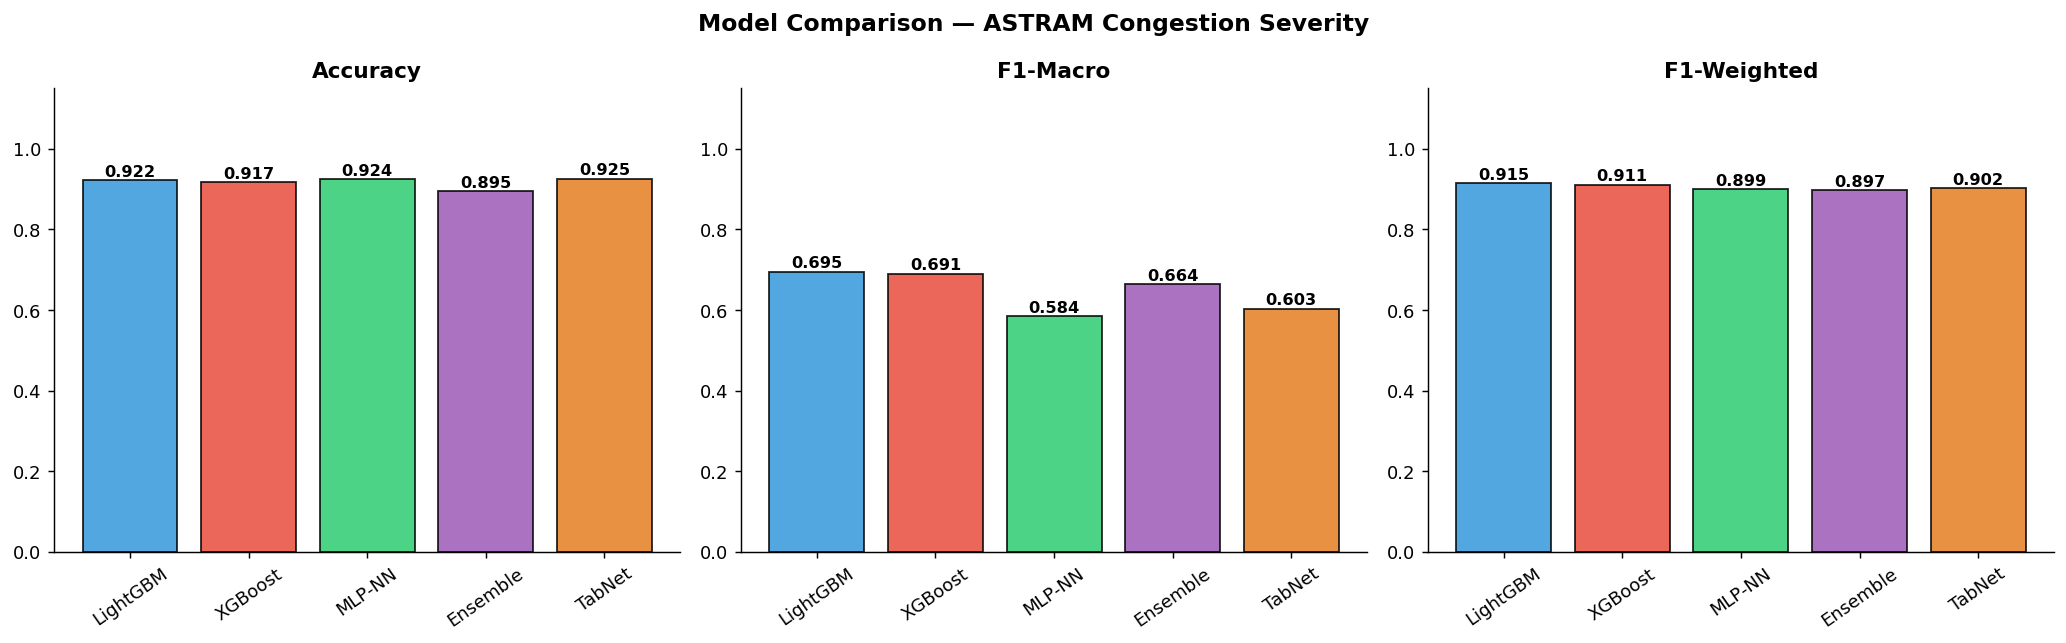

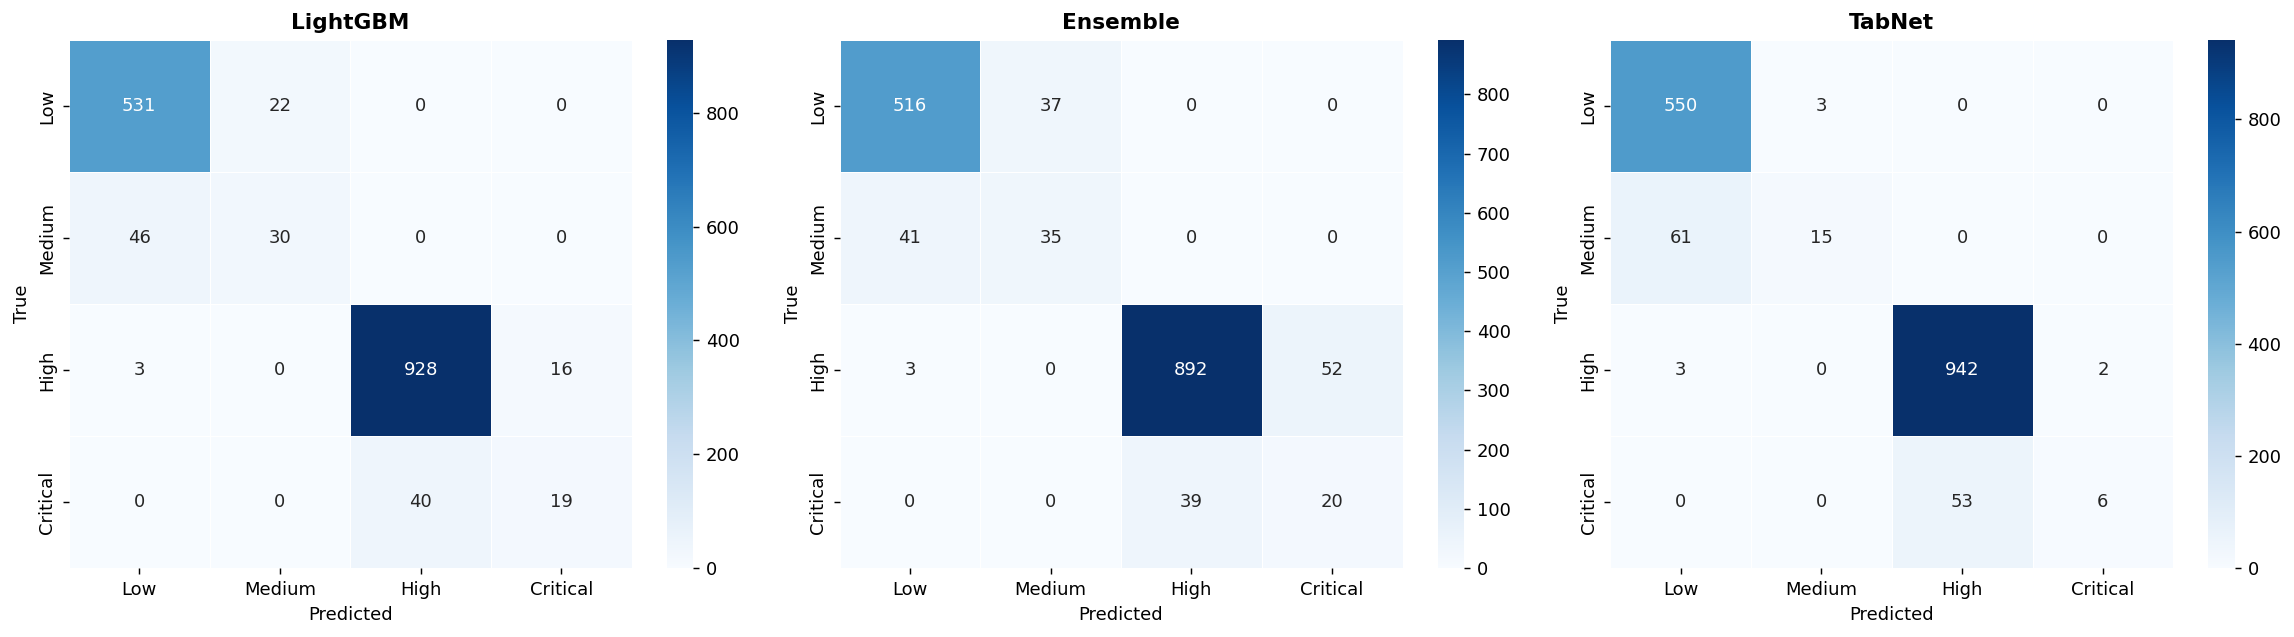

In [39]:
 #CELL 15 ▸ Model Comparison Dashboard
# ════════════════════════════════════════════════════════

results = {
    'LightGBM': [accuracy_score(y_test, lgbm_preds),
                 f1_score(y_test, lgbm_preds, average='macro'),
                 f1_score(y_test, lgbm_preds, average='weighted')],
    'XGBoost':  [accuracy_score(y_test, xgb_preds),
                 f1_score(y_test, xgb_preds, average='macro'),
                 f1_score(y_test, xgb_preds, average='weighted')],
    'MLP-NN':   [accuracy_score(y_test, mlp_preds),
                 f1_score(y_test, mlp_preds, average='macro'),
                 f1_score(y_test, mlp_preds, average='weighted')],
    'Ensemble': [accuracy_score(y_test, ens_preds),
                 f1_score(y_test, ens_preds, average='macro'),
                 f1_score(y_test, ens_preds, average='weighted')],
}
if TABNET_AVAILABLE:
    results['TabNet'] = [accuracy_score(y_test, tn_preds),
                         f1_score(y_test, tn_preds, average='macro'),
                         f1_score(y_test, tn_preds, average='weighted')]

res_df = pd.DataFrame(results, index=['Accuracy', 'F1-Macro', 'F1-Weighted']).T.round(4)
print("\nMODEL COMPARISON")
print(res_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
bar_colors_m = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22']
metrics = ['Accuracy', 'F1-Macro', 'F1-Weighted']

for i, metric in enumerate(metrics):
    vals = res_df[metric]
    bars = axes[i].bar(vals.index, vals.values,
                       color=bar_colors_m[:len(vals)], edgecolor='black', alpha=0.85)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, 1.15)
    axes[i].tick_params(axis='x', rotation=35)
    for b, v in zip(bars, vals.values):
        axes[i].text(b.get_x() + b.get_width()/2, v + 0.01,
                     f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — ASTRAM Congestion Severity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

# ── Confusion matrices ─────────────────────────────────
class_names = [SEVERITY_LABELS[i] for i in range(4)]
plot_models = [('LightGBM', lgbm_preds), ('Ensemble', ens_preds)]
if TABNET_AVAILABLE:
    plot_models.append(('TabNet', tn_preds))

fig, axes = plt.subplots(1, len(plot_models),
                         figsize=(6 * len(plot_models), 5))
if len(plot_models) == 1:
    axes = [axes]

for ax, (name, preds) in zip(axes, plot_models):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, annot_kws={'size': 10})
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

In [40]:
RESOURCE_TABLE = {
    # severity → (min_officers, max_officers, barricade_desc, diversion_desc)
    0: ( 2,  4, 'Cones / indicators only',
              'No diversion needed'),
    1: ( 4,  8, 'Partial barricade (1 lane closed) + 1 marshal',
              'Advisory alternate route via parallel road'),
    2: ( 8, 14, 'Full barricade both sides + 2 marshal points',
              'Mandatory alternate route + digital signage'),
    3: (15, 25, 'Full corridor lockdown + marshal chain',
              'Police-escorted diversion + public advisory + PR alert'),
}

def recommend_resources(severity: int, event_cause: str,
                        is_corridor: bool, hour: int,
                        is_planned: bool = False) -> dict:
    """
    severity   : 0-3 from model prediction
    event_cause: e.g. 'public_event', 'vehicle_breakdown'
    is_corridor: True if on ORR / major Bengaluru corridor
    hour       : start_hour 0-23
    is_planned : True for pre-deployable events
    """
    mn, mx, barricade, diversion = RESOURCE_TABLE[severity]

    # Corridor bonus — denser traffic needs more officers
    if is_corridor:
        mn, mx = int(mn * 1.4), int(mx * 1.4)

    # Peak hour bonus
    is_rush = (7 <= hour <= 10) or (17 <= hour <= 21)
    if is_rush:
        mn, mx = int(mn * 1.25), int(mx * 1.25)

    rec = {
        'priority_flag'  : ['🟢 LOW','🟡 MEDIUM','🟠 HIGH','🔴 CRITICAL'][severity],
        'manpower'       : f'{mn}–{mx} officers',
        'barricading'    : barricade,
        'diversion'      : diversion,
        'impact_estimate': f'~{[15, 30, 60, 90][severity]} min avg delay',
    }

    if is_planned:
        rec['pre_deploy'] = (
            f'Deploy min {mn} officers ≥2h before event start'
        )
    if is_rush:
        rec['peak_note'] = '⚠️ Peak hour active — raise headcount by 25%'

    if event_cause == 'public_event' and severity >= 2:
        rec['special_action'] = (
            '📢 Issue public advisory. Coordinate with event organiser. '
            'Set up crowd control perimeter.'
        )
    if event_cause == 'accident' and severity >= 2:
        rec['special_action'] = (
            '🚑 Ensure ambulance lane maintained. '
            'Contact trauma centre on standby.'
        )

    return rec


# Demo predictions
print("=" * 65)
print("RESOURCE RECOMMENDATION ENGINE — DEMO")
print("=" * 65)

demos = [
    dict(severity=0, event_cause='vehicle_breakdown',
         is_corridor=False, hour=14, is_planned=False),
    dict(severity=1, event_cause='water_logging',
         is_corridor=False, hour=9,  is_planned=False),
    dict(severity=2, event_cause='public_event',
         is_corridor=True,  hour=18, is_planned=True),
    dict(severity=3, event_cause='public_event',
         is_corridor=True,  hour=19, is_planned=True),
]

for d in demos:
    r = recommend_resources(**d)
    print(f"\n{'─'*60}")
    print(f"Event: sev={d['severity']} | cause={d['event_cause']} "
          f"| corridor={d['is_corridor']} | hour={d['hour']:02d}:00")
    for k, v in r.items():
        print(f"  {k:<18}: {v}")

RESOURCE RECOMMENDATION ENGINE — DEMO

────────────────────────────────────────────────────────────
Event: sev=0 | cause=vehicle_breakdown | corridor=False | hour=14:00
  priority_flag     : 🟢 LOW
  manpower          : 2–4 officers
  barricading       : Cones / indicators only
  diversion         : No diversion needed
  impact_estimate   : ~15 min avg delay

────────────────────────────────────────────────────────────
Event: sev=1 | cause=water_logging | corridor=False | hour=09:00
  priority_flag     : 🟡 MEDIUM
  manpower          : 5–10 officers
  barricading       : Partial barricade (1 lane closed) + 1 marshal
  diversion         : Advisory alternate route via parallel road
  impact_estimate   : ~30 min avg delay
  peak_note         : ⚠️ Peak hour active — raise headcount by 25%

────────────────────────────────────────────────────────────
Event: sev=2 | cause=public_event | corridor=True | hour=18:00
  priority_flag     : 🟠 HIGH
  manpower          : 13–23 officers
  barricading  

In [41]:
# ════════════════════════════════════════════════════════
# CELL 17 ▸ End-to-End Inference Function
# ════════════════════════════════════════════════════════

def predict_congestion(
    latitude,
    longitude,
    event_type,        # 'planned' | 'unplanned'
    event_cause,       # 'public_event' | 'vehicle_breakdown' | 'accident' | ...
    start_hour,        # int 0-23
    day_of_week,       # int 0=Mon … 6=Sun
    month,             # int 1-12
    day,               # int 1-31
    corridor,          # e.g. 'ORR East 1' | 'Non-corridor'
    police_station,    # e.g. 'Cubbon Park'
    zone,              # e.g. 'CBD 2' | None
    veh_type=None,
    duration_mins=None,
    junction=None,
) -> dict:

    row = {
        'latitude':          latitude,
        'longitude':         longitude,
        'location_cluster':  int(kmeans.predict([[latitude, longitude]])[0]),
        'pin_code':          560001,      # default Bengaluru; override if known
        'has_end_location':  0,
        'hour':              start_hour,
        'day_of_week':       day_of_week,
        'month':             month,
        'day':               day,
        'day_of_year':       pd.Timestamp(f'2024-{month:02d}-{day:02d}').day_of_year,
        'is_weekend':        int(day_of_week >= 5),
        'is_night':          int(start_hour >= 22 or start_hour <= 5),
        'is_morning_rush':   int(7 <= start_hour <= 10),
        'is_evening_rush':   int(17 <= start_hour <= 21),
        'time_bucket':       time_bucket(start_hour),
        'event_type':        event_type,
        'event_cause':       event_cause,
        'is_corridor':       int((corridor or '') not in ('Non-corridor', '', None)),
        'authenticated_flag': 1,
        'has_description':   1,
        'has_end_time':      int(duration_mins is not None),
        'has_been_closed':   0,
        'duration_mins':     duration_mins or 0,
        'resolution_mins':   0,
        'corridor':          corridor or 'Non-corridor',
        'veh_type_simple':   simplify_veh(veh_type),
        'police_station':    police_station or 'UNKNOWN',
        'zone':              zone or 'UNKNOWN',
        'junction':          junction or 'UNKNOWN',
        'status':            'active',
    }

    inp = pd.DataFrame([row])

    # Encode
    for col, le in label_encoders.items():
        if col in inp.columns:
            v = str(inp[col].iloc[0])
            v = v if v in le.classes_ else le.classes_[0]
            inp[col] = le.transform([v])[0]

    # Align to training feature order
    for col in FEATURE_NAMES:
        if col not in inp.columns:
            inp[col] = 0
    inp = inp[FEATURE_NAMES].fillna(0)
    inp_sc = scaler.transform(inp).astype(np.float32)

    # Collect probabilities
    blocks = [lgbm.predict_proba(inp), xgbm.predict_proba(inp),
              mlp.predict_proba(inp_sc)]
    if TABNET_AVAILABLE:
        blocks.append(tabnet.predict_proba(inp_sc))

    meta_feat = np.hstack(blocks)
    sev_pred  = int(meta_lgb.predict(meta_feat)[0])
    sev_probs = meta_lgb.predict_proba(meta_feat)[0]

    recs = recommend_resources(
        severity    = sev_pred,
        event_cause = event_cause,
        is_corridor = row['is_corridor'] == 1,
        hour        = start_hour,
        is_planned  = event_type == 'planned',
    )

    return {
        'severity_level'      : sev_pred,
        'severity_label'      : SEVERITY_LABELS[sev_pred],
        'confidence'          : float(sev_probs.max()),
        'class_probabilities' : {SEVERITY_LABELS[i]: float(sev_probs[i])
                                 for i in range(4)},
        'recommendations'     : recs,
    }


# ── Test ──────────────────────────────────────────────
result = predict_congestion(
    latitude=12.9716, longitude=77.5946,
    event_type='planned', event_cause='public_event',
    start_hour=18, day_of_week=5, month=3, day=15,
    corridor='ORR East 1', police_station='Cubbon Park', zone='CBD 2',
    duration_mins=180,
)

print("\n" + "=" * 60)
print("🎯 LIVE INFERENCE — Cricket Match, M Chinnasawmy, 6 PM")
print("=" * 60)
print(f"  Severity   : {result['severity_level']} — {result['severity_label']}")
print(f"  Confidence : {result['confidence']:.1%}")
print("\n  Class Probabilities:")
for label, p in result['class_probabilities'].items():
    bar = '█' * int(p * 25)
    print(f"    {label:10}: {p:.1%}  {bar}")
print("\n  Recommendations:")
for k, v in result['recommendations'].items():
    print(f"    {k:<20}: {v}")


🎯 LIVE INFERENCE — Cricket Match, M Chinnasawmy, 6 PM
  Severity   : 2 — High
  Confidence : 97.3%

  Class Probabilities:
    Low       : 0.3%  
    Medium    : 1.0%  
    High      : 97.3%  ████████████████████████
    Critical  : 1.4%  

  Recommendations:
    priority_flag       : 🟠 HIGH
    manpower            : 13–23 officers
    barricading         : Full barricade both sides + 2 marshal points
    diversion           : Mandatory alternate route + digital signage
    impact_estimate     : ~60 min avg delay
    pre_deploy          : Deploy min 13 officers ≥2h before event start
    peak_note           : ⚠️ Peak hour active — raise headcount by 25%
    special_action      : 📢 Issue public advisory. Coordinate with event organiser. Set up crowd control perimeter.


In [42]:
print("=" * 60)
print("PACKAGING ALL ARTIFACTS")
print("=" * 60)

pkl_artifacts = {
    'lgbm_model.pkl'    : lgbm,
    'xgb_model.pkl'     : xgbm,
    'mlp_model.pkl'     : mlp,
    'meta_learner.pkl'  : meta_lgb,
    'scaler.pkl'        : scaler,
    'label_encoders.pkl': label_encoders,
    'kmeans_model.pkl'  : kmeans,
    'feature_names.pkl' : FEATURE_NAMES,
}
for fname, obj in pkl_artifacts.items():
    joblib.dump(obj, fname)
    kb = os.path.getsize(fname) / 1024
    print(f"  ✅ {fname:<30} ({kb:.0f} KB)")

xgbm.save_model('xgb_model.json')
lgbm.booster_.save_model('lgbm_model.txt')
if TABNET_AVAILABLE:
    tabnet.save_model('tabnet_model')
print("  ✅ xgb_model.json + lgbm_model.txt")

# Bundle into zip
ZIP_NAME = 'astram_models_bundle.zip'
bundle_files = list(pkl_artifacts.keys()) + [
    'xgb_model.json', 'lgbm_model.txt',
    'missing_values.png', 'distributions.png', 'temporal_overview.png',
    'geo_clusters.png', 'target_distribution.png',
    'feature_target_correlation.png', 'lgbm_feature_importance.png',
    'mlp_learning_curve.png', 'model_comparison.png', 'confusion_matrices.png',
]
if TABNET_AVAILABLE:
    bundle_files.append('tabnet_model.zip')

with zipfile.ZipFile(ZIP_NAME, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for f in bundle_files:
        if os.path.exists(f):
            zf.write(f)

mb = os.path.getsize(ZIP_NAME) / 1024 / 1024
print(f"\n📦 Bundle: {ZIP_NAME}  ({mb:.1f} MB)")

try:
    from google.colab import files
    files.download(ZIP_NAME)
    print("⬇️  Download started!")
except ImportError:
    print(f"💡 Not in Colab. Find zip at: ./{ZIP_NAME}")



PACKAGING ALL ARTIFACTS
  ✅ lgbm_model.pkl                 (4041 KB)
  ✅ xgb_model.pkl                  (6755 KB)
  ✅ mlp_model.pkl                  (610 KB)
  ✅ meta_learner.pkl               (2072 KB)
  ✅ scaler.pkl                     (2 KB)
  ✅ label_encoders.pkl             (11 KB)
  ✅ kmeans_model.pkl               (33 KB)
  ✅ feature_names.pkl              (0 KB)
Successfully saved model at tabnet_model.zip
  ✅ xgb_model.json + lgbm_model.txt

📦 Bundle: astram_models_bundle.zip  (10.4 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download started!
